In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from pybaselines import Baseline
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
from PIXE_polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_results.ipynb started: Mon, 01 Jun 2026 11:58:56
INFO: SETUP COMPLETE (5421.8750 ms)
---------------------------------------


In [2]:
# fine = True
# DPI = 400
# filename = './/collected_data//2026_05_13//20260513-060516.vspc'
# data = read_json_formatted_file(filename)
# meas_name = filename.split('//')[3].split('.')[0]
# meas_folder = filename.split('//')[2]

# energyPerBin = data['Calibration']['BinSize_keV/Bin'] # keV/bin
# bin_data = data['RawData'][:-1] #remove that overflow bin at position 8191
# total_counts = np.sum(bin_data)
# total_counts_incl = np.sum(data['RawData'])
# # print(bin_data)

# bins = np.arange(0,len(bin_data),1)

# scatter_color = color_schemes['c_dark']

# fig, ax = plt.subplots(figsize=(40,4), dpi=DPI)
# # ax.set_facecolor(color_schemes['c_back'])
# # ax.plot(bins, bin_data, lw=0.75, color=scatter_color[0], zorder=2)
# ax.step(bins, bin_data, lw=0.75, color=scatter_color[3], zorder=2)

# if (len(bin_data) == 8191):
#     ax.set_xlim(0,8193)
#     ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
#     if fine == True:
#        ax.set_xticks(np.arange(0,8193,64),np.arange(0,8193,64)) 
# elif (len(bin_data) == 4095):
#     ax.set_xlim(0,4095)
#     ax.set_xticks(np.arange(0,4097,512),np.arange(0,4097,512))
# elif (len(bin_data) == 2047):
#     ax.set_xlim(0,2047)
#     ax.set_xticks(np.arange(0,2049,512),np.arange(0,2049,512))


# secax = ax.secondary_xaxis('top')
# secax.set_xlim(0,8193)
# secax.set_xticks(np.arange(0,8193,64),list(np.arange(0,(8193*2.3866),(64*2.3866)).round(1)), rotation=30, ha='left')
# secax.set_xlabel('Energy / eV', fontsize=6)
    
# plt.xlabel('MCA channel')
# plt.ylabel('Counts')

# plt.yscale('log')

# plt.grid(which="both")
# plt.tight_layout()

# #----------------- Information Box -----------------#
# #det_pic_file = detector_pic(measurement['det_id'])
# # img = plt.imread(det_pic_file)
# annotation = TextArea(f"X-ray measurement \n {meas_name} \n RAW DATA \n Total Counts: {total_counts}", textprops=dict(color="black", fontsize=5, multialignment='center'))
# # imagebox = OffsetImage(img, zoom=0.05)
# stacked = VPacker(children=[annotation],
#                 align="center",
#                 pad=0,
#                 sep=5)

# ab = AnnotationBbox(offsetbox=stacked, xy=(0.9,0.85), xycoords='axes fraction', frameon=True)

# ax.add_artist(ab)
# #----------------- Information Box -----------------#


# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.png', dpi=DPI)
# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.pdf', dpi=DPI)

In [3]:
# f_n = all_files_from_measSet('2026_02_26')
# f_n = all_files_from_measSet('2026_02_27')
# f_n = all_files_from_measSet('2026_03_25')
# f_n = all_files_from_measSet('collected_data//2026_05_13')

In [4]:
def dual_print(*args, name, **kwargs):
    print(*args)
    with open(name, 'a') as out:
        print(*args, **kwargs, file=out)

In [5]:
def data_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.arpls(bin_data, lam=lam, max_iter=400)
    subtracted = bin_data - baseline
    return baseline, subtracted

def data_baseline_subtracted(file:str, select_window:list):
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_selected = bin_data[select_window[0]:select_window[1]+1]
    bin_data_zerofixed = np.where(bin_data_selected == 0, 1, bin_data_selected)
    data_err = np.sqrt(bin_data_zerofixed)
    
    bins = np.arange(0,len(bin_data),1)
    bins_selected = bins[select_window[0]:select_window[1]+1]
    bins_err = np.array([2]*len(bins))
    
    bl_full, sub_full = data_baseline(bin_data, bins)
    bl_sw, sub_sw = data_baseline(bin_data_selected, bins_selected)
    
    g_sum_full = np.sum(sub_full[1030:1080])
    g_sum_sw = np.sum(sub_sw[30:80])
    
    print('Spectrum Full:', g_sum_full)
    print('Spectrum SW:', g_sum_sw)
    print('Difference Full:',np.sum(bin_data[1030:1080]) - g_sum_full, (np.sum(bin_data[1030:1080]) - g_sum_full)/np.sum(bin_data[1030:1080]))
    print('Difference SW:',np.sum(bin_data[1030:1080]) - g_sum_sw, (np.sum(bin_data[1030:1080]) - g_sum_sw)/np.sum(bin_data[1030:1080]))
    
    
    plt.figure(figsize=(6,3), dpi=300)
    plt.step(bins, bin_data, alpha=1, lw=0.5, color=color_schemes['c_rainbow'][0], label='Original Spectrum')
    plt.plot(bins, bl_full, alpha=0.8, lw=0.8, ls='-.', color=color_schemes['c_rainbow'][1], label='Baseline')
    plt.step(bins, sub_full, lw=0.5, color=color_schemes['c_rainbow'][5], label='Baseline subtracted spectrum')
    
    plt.plot(bins_selected, bl_sw, lw=0.8, alpha=0.8, ls='-.', color=color_schemes['c_rainbow'][2], label='Baseline selected window')
    plt.step(bins_selected, sub_sw, lw=0.5, color=color_schemes['c_rainbow'][6], label='Baseline subtracted spectrum selected window')
    
    # plt.yscale('log')
    
    plt.xlabel(r'MCA channel $N_{\mathrm{c}}$')
    plt.ylabel('Counts')
    
    plt.ylim(0,7500)
    plt.xlim(select_window[0],select_window[1])
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'./plots/{file.split('//')[-1].split('.')[0]}_0_arplsBaselineSubstracted.png', transparent=False, dpi=300)
    

# data_baseline_subtracted('.//collected_data//2026_05_13//20260513-160638.vspc', [1000,1200])

In [6]:
# def peak_fitter(file:str, init_values:list, gauss_ident:str,
#                 select_window:list, xlim:list,
#                 substract_flag:bool = False, region_flag:str = 'roi_x'):
    
#     data = read_json_formatted_file(file)
    
#     offset_start = select_window[0] - xlim[0]
#     offset_end = select_window[1] - xlim[0] + 1
    
#     if (offset_start <= 0):
#         raise ValueError('FITTER: The lower xlim bound is insufficiently low.')
        
    
#     bin_data = np.array(data['RawData'][:-1])
#     bin_data_selwindow = bin_data[select_window[0]:select_window[1]+1]
#     bin_data_xlim = bin_data[xlim[0]:xlim[1]+1]
    
#     bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    
    
#     bins = np.arange(0,len(bin_data),1)
#     bins_selwindow = bins[select_window[0]:select_window[1]+1]
#     bins_xlim = bins[xlim[0]:xlim[1]+1]
    
#     data_err = np.sqrt(bin_data_zerofixed)
#     bins_err = np.array([2]*len(bins_selwindow))
    
#     bl, subtr_data = data_baseline(bin_data_xlim, bins_xlim)
#     bl, subtr_data_fit = data_baseline(bin_data_selwindow, bins_selwindow)
#     bl, subtr_data_full = data_baseline(bin_data, bins)
    
    
    
#     # roi_x: arPLS in xlim, fit in select_window
#     # roi_f: arPLS in select_window, fit in select_window
#     # roi_t; arPLS in full data, fit in select_window
#     if (substract_flag == True):
#         if (region_flag == 'roi_x'):
#             if (gauss_ident == 'single'):
#                 beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data[offset_start:offset_end],
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             elif (gauss_ident == 'double'):
#                 beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data[offset_start:offset_end],
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             elif (gauss_ident == 'multi'):
#                 beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data[offset_start:offset_end],
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             return beta, subtr_data
#         elif (region_flag == 'roi_f'):
#             if (gauss_ident == 'single'):
#                 beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data_fit,
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             elif (gauss_ident == 'double'):
#                 beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data_fit,
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             elif (gauss_ident == 'multi'):
#                 beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
#                             x=bins_selwindow, y=subtr_data_fit,
#                             xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
#             return beta, subtr_data_fit
#         elif (region_flag == 'roi_t'):
#             if (gauss_ident == 'single'):
#                 beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
#                             x=bins, y=subtr_data_full,
#                             xerr=np.array([2]*len(bins)), yerr=data_err)
#             elif (gauss_ident == 'double'):
#                 beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
#                             x=bins, y=subtr_data_full,
#                             xerr=np.array([2]*len(bins)), yerr=data_err)
#             elif (gauss_ident == 'multi'):
#                 beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
#                             x=bins, y=subtr_data_full,
#                             xerr=np.array([2]*len(bins)), yerr=data_err)
#             return beta, subtr_data_full
    

In [7]:
def both_chi_squared(bin_data:list, fit_data:list, params:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    dof = len(bin_data) - len(params)
    var = np.sqrt(np.var(bin_data))
    return sum(((fit_data-bin_data)/ var)**2), sum(((fit_data-bin_data)/ var)**2) / dof

def goodness_of_fit(bin_data:list, fit_data:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    
    rss = sum((bin_data - fit_data)**2)
    tss = sum((bin_data - np.average(bin_data))**2)
    return 1 - rss/tss

In [8]:
def peak_fitter(file:str, init_values:list, gauss_ident:str,
                select_window:list, xlim:list,
                substract_flag:bool = False, region_flag:str = 'roi_x', lam:int = 1e2):
    
    data = read_json_formatted_file(file)
    
    offset_start = select_window[0] - xlim[0]
    offset_end = select_window[1] - xlim[0] + 1
    
    if (offset_start <= 0):
        raise ValueError('FITTER: The lower xlim bound is insufficiently low.')
        
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_selwindow = bin_data[select_window[0]:select_window[1]+1]
    bin_data_xlim = bin_data[xlim[0]:xlim[1]+1]
    
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    
    
    bins = np.arange(0,len(bin_data),1)
    bins_selwindow = bins[select_window[0]:select_window[1]+1]
    bins_xlim = bins[xlim[0]:xlim[1]+1]
    
    data_err = np.sqrt(bin_data_zerofixed)
    bins_err = np.array([2]*len(bins_selwindow))
    
    bl, subtr_data = data_baseline(bin_data_xlim, bins_xlim, lam=lam)
    bl, subtr_data_fit = data_baseline(bin_data_selwindow, bins_selwindow, lam=lam)
    bl, subtr_data_full = data_baseline(bin_data, bins, lam=lam)
    
    if gauss_ident == 'single':
        use_func = gauss_func  
    elif (gauss_ident == 'double'):
        use_func = double_gauss_func
    elif (gauss_ident == 'multi'):
        use_func = multi_gauss
      
    # roi_x: arPLS in xlim, fit in select_window
    # roi_f: arPLS in select_window, fit in select_window
    # roi_t; arPLS in full data, fit in select_window
    if (substract_flag == True):
        if (region_flag == 'roi_x'):
            # GAUSS IDENT = SINGLE, DOUBLE, MULTI
            beta = evaluator_curvefit(func=gauss_ident, param_list=init_values, boundary_list='',
                        x=bins_selwindow, y=subtr_data[offset_start:offset_end],
                        xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            
            chi, redX = both_chi_squared(subtr_data[offset_start:offset_end], use_func(beta['param'],bins_selwindow), beta['param'])
            gof = goodness_of_fit(subtr_data[offset_start:offset_end], use_func(beta['param'],bins_selwindow))
            
            return beta, subtr_data, gof, chi, redX
        elif (region_flag == 'roi_f'):
            beta = evaluator_curvefit(func=gauss_ident, param_list=init_values, boundary_list='',
                        x=bins_selwindow, y=subtr_data_fit,
                        xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])

            chi, redX = both_chi_squared(subtr_data_fit, use_func(beta['param'],bins_selwindow), beta['param'])
            gof = goodness_of_fit(subtr_data_fit, use_func(beta['param'],bins_selwindow))
            
            return beta, subtr_data_fit, gof, chi, redX
        elif (region_flag == 'roi_t'):
            beta = evaluator_curvefit(func=gauss_ident, param_list=init_values, boundary_list='',
                        x=bins, y=subtr_data_full,
                        xerr=np.array([2]*len(bins)), yerr=data_err)
            
            chi, redX = both_chi_squared(subtr_data_full, use_func(beta['param'],bins), beta['param'])
            gof = goodness_of_fit(subtr_data_full, use_func(beta['param'],bins))
            
            return beta, subtr_data_full, gof, chi, redX
        
    elif (substract_flag == False):
        # GAUSS IDENT = SINGLE, DOUBLE, MULTI
        beta = evaluator_curvefit(func=gauss_ident, param_list=init_values, boundary_list='',
                    x=bins_selwindow, y=bin_data_selwindow,
                    xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
        
        chi, redX = both_chi_squared(bin_data_selwindow, use_func(beta['param'],bins_selwindow), beta['param'])
        gof = goodness_of_fit(bin_data_selwindow, use_func(beta['param'],bins_selwindow))
        
        return beta, subtr_data, gof, chi, redX
    

In [9]:
def all_peaks_one_measurement(file:str, peaks:list, xlim:list, ylim:list, info:list, col_flag:bool, identifier:str, gauss_ident:list):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]}')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
        beta= peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p])
        beta_export = [beta['param'],beta['errors']]
        
        
        if (gauss_ident[p] == 'single'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'single_lin'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_linear_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
              
        
            
        csv_file_name = f'.//peak_idents//{meas_folder}//{meas_name}_peaks_{identifier}.csv'
        
        with open(csv_file_name, mode='a', newline='', encoding='utf-8') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerows(beta_export)
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [10]:
def fit_result_printer(beta:dict, roi_x:list, roi_fit:list, gauss_type:str, r_flag:str):
    param = beta['param']
    errors = beta['errors']
    
    print('=========== REGION of INTEREST ===========')
    if (r_flag == 'roi_t'):
        print(f'\u21e8 full MCA selection:'.ljust(26) + '[   0, 8190]'.ljust(15))
    else:
        print(f'full MCA selection:'.ljust(25) + '[   0, 8190]'.ljust(15))
    if (r_flag == 'roi_x'):
        print(f'\u21e8 x-axis selection:'.ljust(26) + f'{roi_x}'.ljust(15))
    else:
        print(f'x-axis selection:'.ljust(25) + f'{roi_x}'.ljust(15))
    if (r_flag == 'roi_f'):
        print(f'\u21e8 fit window selection:'.ljust(26) + f'{roi_fit}'.ljust(15))
    else:
        print(f'fit window selection:'.ljust(25) + f'{roi_fit}'.ljust(15))
    print('=========== REGION of INTEREST ===========')
        
    print('\n')
        
    if (gauss_type == 's'):
        print('=========== FIT RESULTS ===========')
        print(f'Height:'.ljust(7) + f' {param[0]:.3f}'.rjust(10) +  f' \u00B1 {errors[0]:.3f}')
        print(f'Center:'.ljust(7) + f' {param[1]:.3f}'.rjust(10) +  f' \u00B1 {errors[1]:.3f}')
        print(f'Width:'.ljust(7)  + f'{np.abs(param[2]):.3f}'.rjust(10)  +  f' \u00B1 {errors[2]:.3f}')
        print(f'FWHM:'.ljust(7)   + f'{np.abs(param[2])*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[2]*(2*np.log(2)):.3f}')
        print('=========== FIT RESULTS ===========')
    elif (gauss_type == 'd'):
        print('=========== FIT RESULTS 1 of 2 ===========')
        print(f'Height A:'.ljust(9) + f' {param[0]:.3f}'.rjust(10) +  f' \u00B1 {errors[0]:.3f}')
        print(f'Center A:'.ljust(9) + f' {param[1]:.3f}'.rjust(10) +  f' \u00B1 {errors[1]:.3f}')
        print(f'Width A:'.ljust(9)  + f'{np.abs(param[2]):.3f}'.rjust(10)  +  f' \u00B1 {errors[2]:.3f}')
        print(f'FWHM A:'.ljust(9)   + f'{np.abs(param[2])*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[2]*(2*np.log(2)):.3f}')
        print('=========== FIT RESULTS 2 of 2 ===========')
        print(f'Height B:'.ljust(9) + f' {param[3]:.3f}'.rjust(10) +  f' \u00B1 {errors[3]:.3f}')
        print(f'Center B:'.ljust(9) + f' {param[4]:.3f}'.rjust(10) +  f' \u00B1 {errors[4]:.3f}')
        print(f'Width B:'.ljust(9)  + f'{np.abs(param[5]):.3f}'.rjust(10)  +  f' \u00B1 {errors[5]:.3f}')
        print(f'FWHM B:'.ljust(9)   + f'{np.abs(param[5])*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[5]*(2*np.log(2)):.3f}')
        print('=========== END of FIT RESULTS ===========')
    elif (gauss_type == 'm'):
        for i in range(0,len(param),3):
            res_id = int(i/3 + 1)
            print(f'=========== FIT RESULTS {res_id} of {int(len(param)/3)} ===========')
            print(f'Height {res_id}:'.ljust(9) + f' {param[i]:.3f}'.rjust(10) +  f' \u00B1 {errors[i]:.3f}')
            print(f'Center {res_id}:'.ljust(9) + f' {param[i+1]:.3f}'.rjust(10) +  f' \u00B1 {errors[i+1]:.3f}')
            print(f'Width {res_id}:'.ljust(9)  + f'{np.abs(param[i+2]):.3f}'.rjust(10)  +  f' \u00B1 {errors[i+2]:.3f}')
            print(f'FWHM {res_id}:'.ljust(9)   + f'{np.abs(param[i+2])*(2*np.sqrt(2*np.log(2))):.3f}'.rjust(10) +  f' \u00B1 {errors[i+2]*(2*np.sqrt(2*np.log(2))):.3f}')
        print('=========== END of FIT RESULTS ===========')

In [11]:
def fit_param_to_energy(param:list,ecal:list):
    energy = []
    for i in range(0,len(param),3):
        height = np.abs(param[i])
        center = np.abs(param[i+1])
        width  = np.abs(param[i+2])
        fwhm = width * 2*np.sqrt(2*np.log(2))
        
        ecal_dc = ecal[0]
        ecal_dc_err = ecal[3]
        
        ecal_lin = ecal[1]
        ecal_lin_err = ecal[4]
        
        ecal_sq = ecal[2]
        ecal_sq_err = ecal[5]
        
        energy.append(height)
        energy.append(ecal_dc + center*ecal_lin + center**2*ecal_sq)
        energy.append(ecal_dc_err + center*ecal_lin_err + center**2*ecal_sq_err)
        energy.append(width*ecal_lin + width**2*ecal_sq)
        energy.append(width*ecal_lin_err + width**2*ecal_sq_err)
        energy.append(fwhm*ecal_lin + fwhm**2*ecal_sq)
        energy.append(fwhm*ecal_lin_err + fwhm**2*ecal_sq_err)
    
    return energy

# ecalHWs = [239,7.471,1.467e-5,56.68,0.061,0.795e-5] # EG 3400
ecalHWs = [-56.862,2.3866,-6.032e-7,72.989,0.0294,2.762e-6] # EG 10922

def energy_printer(energy:list):
    for i in range(0,len(energy),7):
        print('|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|')
        print(f'Height: {energy[i]:.3f}')
        print(f'Center: {energy[i+1]:.3f} \u00b1 {energy[i+2]:.3f}')
        print(f'Width: {energy[i+3]:.3f} \u00b1 {energy[i+4]:.3f}')
        print(f'FWHM: {energy[i+5]:.3f} \u00b1 {energy[i+6]:.3f}')
        print('|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|')
    

In [12]:
def find_selection_window(peaks,bin_grad,gauss_type):
    if (gauss_type == 's'):
        start_idx = peaks[1]
        #LEFT
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    elif (gauss_type == 'd'):
        #LEFT
        start_idx = np.min([peaks[1],peaks[4]])
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        start_idx = np.max([peaks[1],peaks[4]])
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
    
    elif (gauss_type == 'm'):
        #LEFT
        start_idx = np.min([peaks[1],peaks[-2]])
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        start_idx = np.max([peaks[1],peaks[-2]])
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    return select_window

def selection_fitter_plotter(file:str, peaks:list,
                             xlim:list, ylim:list,
                             info:list, col_flag:bool,
                             identifier:str, gauss_ident:list,
                             s_flag:bool=False, r_flag:str='roi_fit',
                             chi_flag:bool=False, lam:int=1e2):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_rainbow']
        gcp = [1,2,3,5,6,7]
        # gauss_color = color_schemes['c_complementary']
        # gcp = [0,3,5,6,4,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_grad = np.gradient(bin_data)
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.5, alpha=0.5, color='black', zorder=3, label='unsubtracted data')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
               
        if (gauss_ident[p] == 'single'): 
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='s')
            plt.fill_betweenx(y=[0,peaks[p][0]],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1, label='selection window')
            
            if (chi_flag == True):
                lam_range = np.logspace(1,10,10)
                chi_min = [0,10]
                for lam_ in lam_range:
                    try:
                        _,_,_, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam_)
                        # print(lam, chi)
                        if chi < chi_min[1]:
                            chi_min[0] = lam_
                            chi_min[1] = chi
                    except:
                        pass
                if (chi_min[0] == 0):
                    chi_min[0] = lam
                    chi_min[1] = 'None'  
                
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=chi_min[0])
            else:
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam)
            
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='s', r_flag=r_flag)
            
            if (chi_flag == True):
                print(f'lam: 10^{int(np.log10(chi_min[0]))}')
            else:
                print(f'lam: 10^{int(np.log10(lam))}')
            print(f'GOF: {gof:.4f}')
            print(f'chi²: {chi:.4f}', )
            print(f'red. chi²: {redX:.4f}')
            energy_list = fit_param_to_energy(param=beta['param'],ecal=ecalHWs)
            energy_printer(energy_list)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            
            
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='d')
            plt.fill_betweenx(y=[0,np.max([peaks[p][0],peaks[p][3]])*1.1],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1, label='selection window')
            
            if (chi_flag == True):
                lam_range = np.logspace(1,10,10)
                chi_min = [0,10]
                for lam_ in lam_range:
                    try:
                        _,_,_, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam_)
                        # print(lam, chi)
                        if chi < chi_min[1]:
                            chi_min[0] = lam_
                            chi_min[1] = chi
                    except:
                        pass  
                if (chi_min[0] == 0):
                    chi_min[0] = lam
                    chi_min[1] = 'None'
                    
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=chi_min[0])
            else:
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam)
                
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='d', r_flag=r_flag)
            
            if (chi_flag == True):
                print(f'lam: 10^{int(np.log10(chi_min[0]))}')
            else:
                print(f'lam: 10^{int(np.log10(lam))}')
            print(f'GOF: {gof:.4f}')
            print(f'chi²: {chi:.4f}', )
            print(f'red. chi²: {redX:.4f}')
            energy_list = fit_param_to_energy(param=beta['param'],ecal=ecalHWs)
            energy_printer(energy_list)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'multi'):
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='m')
            plt.fill_betweenx(y=[0,ylim[1]],x1=select_window[0],x2=select_window[1],color=color_schemes['c_back'], zorder=2, alpha=0.3, lw=0.1, label='selection window')
            if (chi_flag == True):
                lam_range = np.logspace(1,10,10)
                chi_min = [1,10]
                for lam_ in lam_range:
                    try:
                        _,_,_, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam_)
                        # print(lam, chi)
                        if chi < chi_min[1]:
                            chi_min[0] = lam_
                            chi_min[1] = chi
                    except:
                        pass  
                if (chi_min[0] == 0):
                    chi_min[0] = lam
                    chi_min[1] = 'None'
                    
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=chi_min[0])
            else:
                beta, sub_sw, gof, chi, redX = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag, lam=lam)
        
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='m', r_flag=r_flag)
            
            # dual_print(f'GOF: {gof}', name=f'test_{identifier}.txt')
            if (chi_flag == True):
                print(f'lam: 10^{int(np.log10(chi_min[0]))}')
            else:
                print(f'lam: 10^{int(np.log10(lam))}')
            print(f'GOF: {gof:.4f}')
            print(f'chi²: {chi:.4f}', )
            print(f'red. chi²: {redX:.4f}')
            energy_list = fit_param_to_energy(param=beta['param'],ecal=ecalHWs)
            energy_printer(energy_list)
                
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][-2]*1.05)
            
            plt.plot(bins[gauss_left:gauss_right],multi_gauss(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color="#FF00FF", zorder=3, label=fr'{int(len(beta['param'])/3)} Gaussian - line fit: $\chi^2$ = {chi:.4f}')
            for i in range(0,len(beta['param']),3):
                plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][i:i+3], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[int(i/3)]], zorder=3, label=fr'{info[int(i/3)+1]} - line fit')
            
    if (s_flag == True and r_flag == 'roi_x'):
        plt.step(bins[xlim[0]:xlim[1]+1], sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
    elif (s_flag == True and r_flag == 'roi_f'):
        plt.step(bins[select_window[0]:select_window[1]+1], sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
    elif (s_flag == True and r_flag == 'roi_t'):
        plt.step(bins, sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
            
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

## 3400 (~7.6 eV/MCA) @ 8192 10h

In [13]:
file_to_analyze = './/collected_data//2026_05_13//20260513-160638.vspc'

init_val1 = [[1800,7820,19]]
init_val2 = [[10500,1780,12,51800,1830,10,2200,1876,10]]
init_val3 = [[2000,3460,15]]
init_val4 = [[396,389,3.8,5000,417,10,13000,434,10,5000,460,10,2000,487,10]]
xlim1 = [7700,8000]
xlim2 = [1700,1950]
xlim3 = [3350,3550]
xlim4 = [360,520]
ylim1 = [0,2000]
ylim2 = []
ylim3 = [0,2300]
ylim4 = [0,22000]
info1 = ['Americium', r'$\gamma_{2,0}$']
info2 = ['Neptunium', r'$L_3M_5$', 'test1','test2', 'test3']
info3 = ['Americium', r'$\gamma_{4,0}$']
info4 = ['Neptunium', r'$M_{??}$', r'$M_5N_{6,7}$', r'$M_4N_6 + M_5O_3$', r'$M_3N{4,5} + M_5P_3$', r'$M_{???}$', '???']
gauss1 = ['single']
gauss2 = ['multi']
gauss3 = ['single']
gauss4 = ['multi']


# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0s', gauss_ident=gauss1, s_flag=True, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0sf', gauss_ident=gauss1, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0st', gauss_ident=gauss1, s_flag=True, r_flag='roi_t')

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3s', gauss_ident=gauss3, s_flag=False, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3s', gauss_ident=gauss3, s_flag=True, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3sf', gauss_ident=gauss3, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3st', gauss_ident=gauss3, s_flag=True, r_flag='roi_t')

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2s', gauss_ident=gauss2, s_flag=True, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2sf', gauss_ident=gauss2, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2st', gauss_ident=gauss2, s_flag=True, r_flag='roi_t')

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val4, xlim=xlim4, ylim=ylim4, info=info4, col_flag=False, identifier='4s', gauss_ident=gauss4, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val4, xlim=xlim4, ylim=ylim4, info=info4, col_flag=False, identifier='4sf', gauss_ident=gauss4, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val4, xlim=xlim4, ylim=ylim4, info=info4, col_flag=False, identifier='4st', gauss_ident=gauss4, s_flag=True, r_flag='roi_t')


# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='1', gauss_ident=gauss2)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3', gauss_ident=gauss3)

## 10922 (~2.387 eV/MCA) @ 8192 10h

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [1150, 1650]   
fit window selection:    [1239, 1586]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 6 ===========
Height 1:   321.480 ± 12.987
Center 1:  1244.003 ± 6.851
Width 1:     40.608 ± 5.850
FWHM 1:      95.626 ± 13.775
=========== FIT RESULTS 2 of 6 ===========
Height 2:  1133.679 ± 41.127
Center 2:  1341.549 ± 0.454
Width 2:     15.170 ± 0.428
FWHM 2:      35.722 ± 1.008
=========== FIT RESULTS 3 of 6 ===========
Height 3:  5832.123 ± 11.103
Center 3:  1396.506 ± 0.193
Width 3:     27.151 ± 0.401
FWHM 3:      63.936 ± 0.943
=========== FIT RESULTS 4 of 6 ===========
Height 4:  4458.339 ± 123.869
Center 4:  1461.902 ± 0.772
Width 4:     20.720 ± 0.713
FWHM 4:      48.793 ± 1.680
=========== FIT RESULTS 5 of 6 ===========
Height 5:  1303.625 ± 202.205
Center 5:  1501.101 ± 2.220
Width 5:     18.370 ± 1.599
FWHM 5:      43.258 ± 3.764
=====

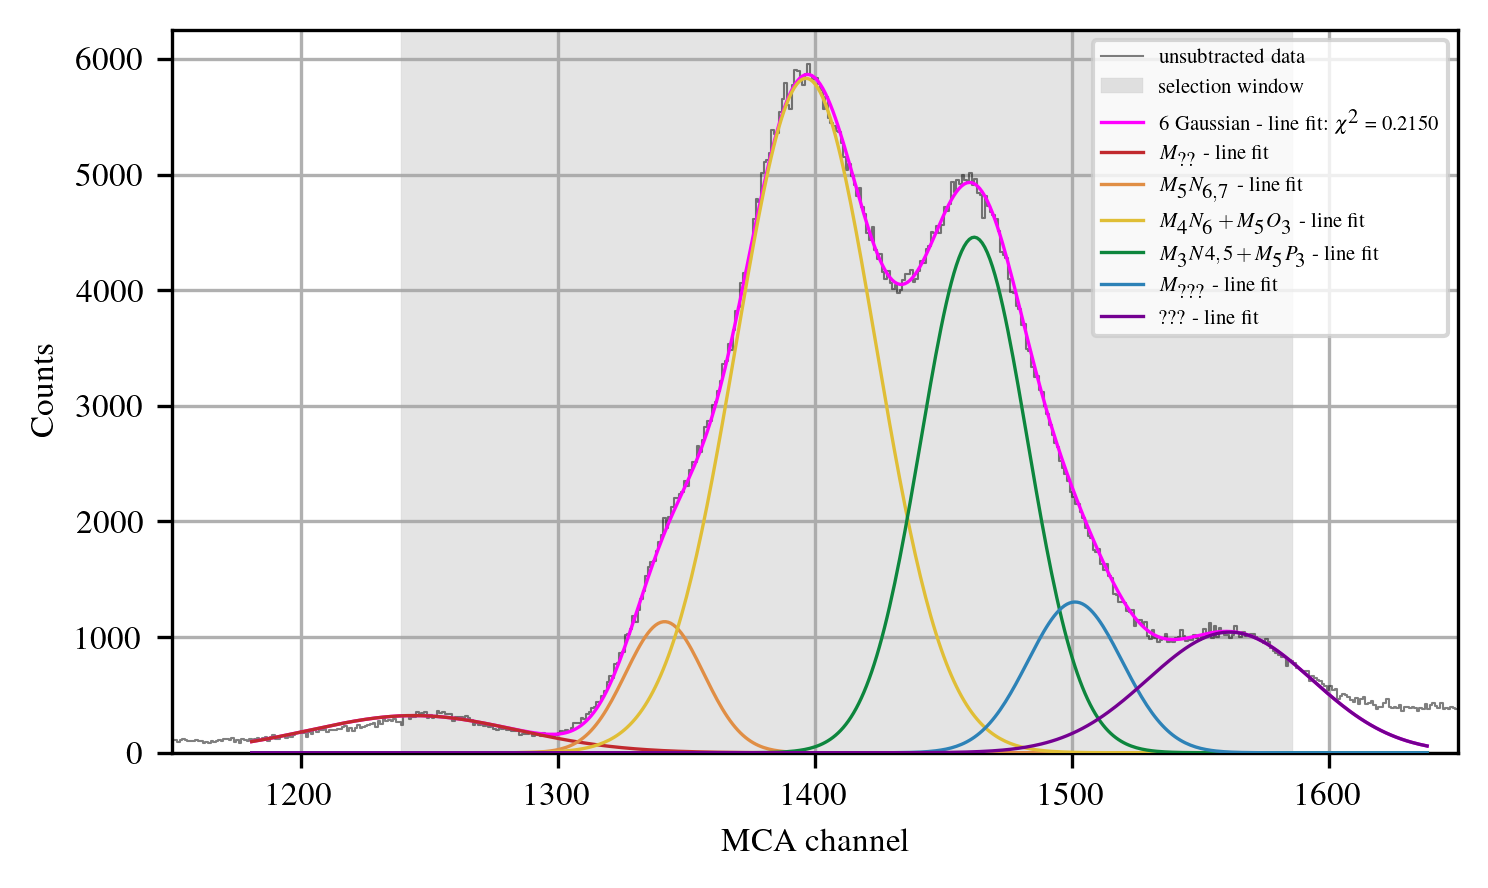

c:\Users\schum\Documents\GitHub\IBA-Bonn\Study_2602_PIXEDetector\PIXE_functions.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(use_func, x, y, p0=params, maxfev=10000)


=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [1150, 1650]   
fit window selection:    [1239, 1586]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 6 ===========
Height 1:   193.678 ± 11.782
Center 1:  1252.278 ± 1.508
Width 1:     14.841 ± 1.604
FWHM 1:      34.947 ± 3.777
=========== FIT RESULTS 2 of 6 ===========
Height 2:  1008.387 ± 31.612
Center 2:  1341.948 ± 0.382
Width 2:     13.865 ± 0.346
FWHM 2:      32.651 ± 0.814
=========== FIT RESULTS 3 of 6 ===========
Height 3:  5610.826 ± 10.307
Center 3:  1396.470 ± 0.180
Width 3:     27.061 ± 0.340
FWHM 3:      63.725 ± 0.801
=========== FIT RESULTS 4 of 6 ===========
Height 4:  4180.865 ± 151.644
Center 4:  1461.521 ± 0.922
Width 4:     20.175 ± 0.701
FWHM 4:      47.509 ± 1.651
=========== FIT RESULTS 5 of 6 ===========
Height 5:  1273.242 ± 178.188
Center 5:  1500.182 ± 2.768
Width 5:     19.033 ± 1.857
FWHM 5:      44.818 ± 4.373
======

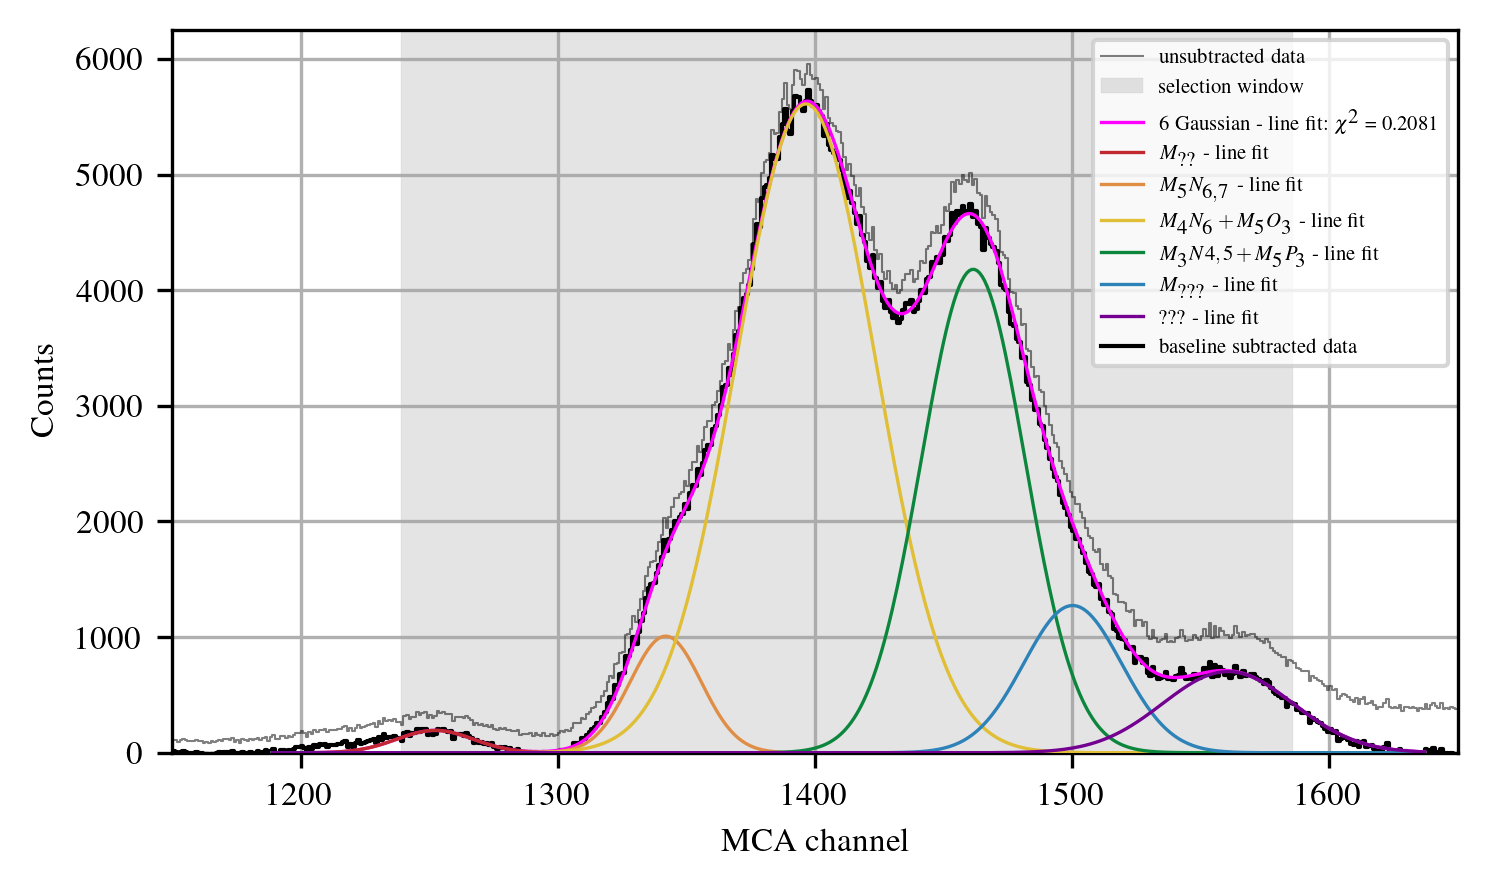

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [5530, 6100]   
fit window selection:    [5696, 6062]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1:  3886.250 ± 13.785
Center 1:  5763.912 ± 0.273
Width 1:     48.148 ± 0.382
FWHM 1:     113.379 ± 0.899
=========== FIT RESULTS 2 of 3 ===========
Height 2: 16598.991 ± 15.280
Center 2:  5892.656 ± 0.057
Width 2:     35.508 ± 0.070
FWHM 2:      83.615 ± 0.166
=========== FIT RESULTS 3 of 3 ===========
Height 3:   819.731 ± 15.404
Center 3:  6027.490 ± 1.239
Width 3:     39.952 ± 1.834
FWHM 3:      94.080 ± 4.318
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9996
chi²: 0.1293
red. chi²: 0.0004
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 3886.250
Center: 13679.250 ± 334.209
Width: 114.908 ± 1.422
FWHM: 270.583 ± 3.369
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-

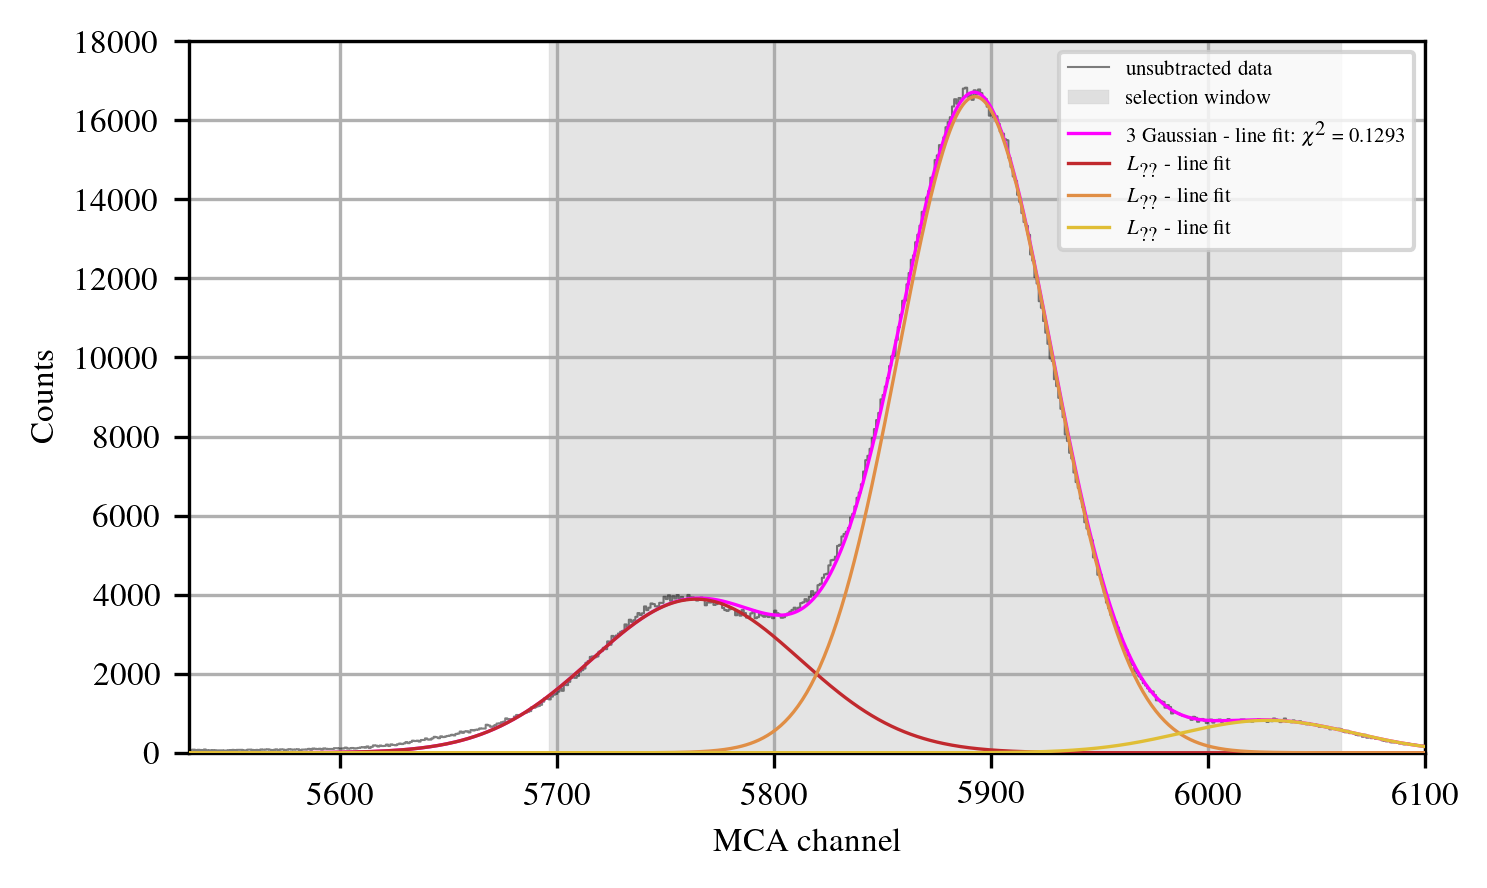

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [5530, 6100]   
fit window selection:    [5696, 6062]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1:    96.382 ± 15.429
Center 1:  5767.541 ± 6.364
Width 1:     26.426 ± 5.767
FWHM 1:      62.229 ± 13.581
=========== FIT RESULTS 2 of 3 ===========
Height 2: 776353.856 ± 1099267477.608
Center 2:  5893.177 ± 7.777
Width 2:     37.747 ± 78.740
FWHM 2:      88.887 ± 185.418
=========== FIT RESULTS 3 of 3 ===========
Height 3: -762001.177 ± 1099267481.584
Center 3:  5893.166 ± 8.059
Width 3:     37.858 ± 80.455
FWHM 3:      89.149 ± 189.457
=========== END of FIT RESULTS ===========
lam: 10^3
GOF: 0.9998
chi²: 0.0771
red. chi²: 0.0002
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 96.382
Center: 13687.887 ± 334.431
Width: 63.069 ± 0.779
FWHM: 148.514 ± 1.840
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|

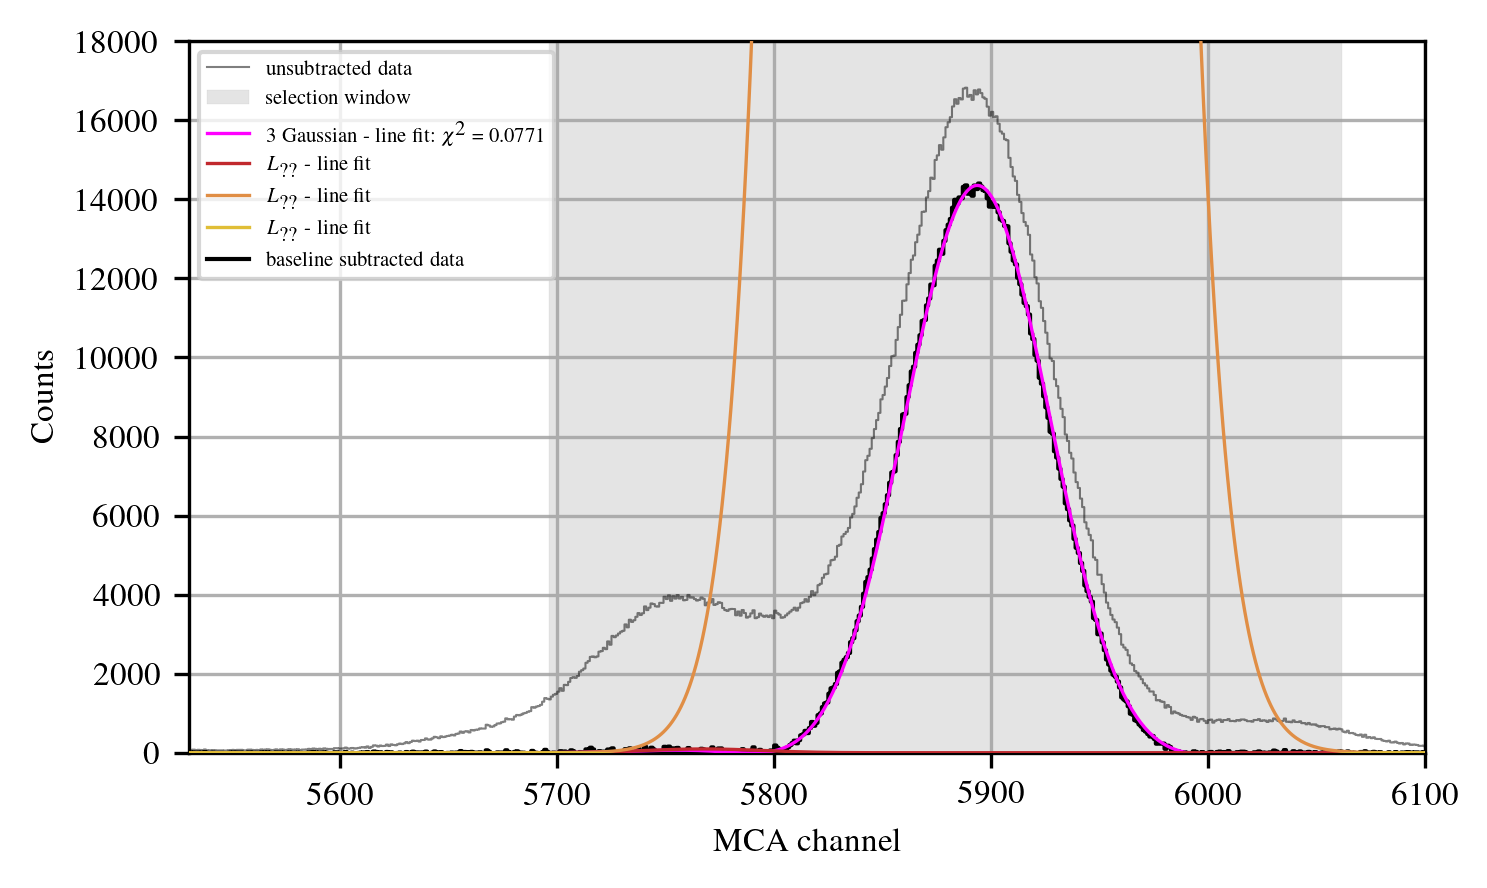

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3300, 3900]   
fit window selection:    [3390, 3761]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:  1745.145 ± 8.993
Center 1:  3397.812 ± 0.286
Width 1:     25.658 ± 0.338
FWHM 1:      60.419 ± 0.796
=========== FIT RESULTS 2 of 4 ===========
Height 2:   187.132 ± 3.562
Center 2:  3493.847 ± 2.470
Width 2:     48.297 ± 2.503
FWHM 2:     113.731 ± 5.894
=========== FIT RESULTS 3 of 4 ===========
Height 3:  1425.022 ± 4.408
Center 3:  3647.516 ± 0.119
Width 3:     27.650 ± 0.139
FWHM 3:      65.110 ± 0.326
=========== FIT RESULTS 4 of 4 ===========
Height 4:   299.567 ± 12.309
Center 4:  3762.366 ± 3.995
Width 4:     30.412 ± 2.680
FWHM 4:      71.615 ± 6.310
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9977
chi²: 0.8423
red. chi²: 0.0023
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 1745.145

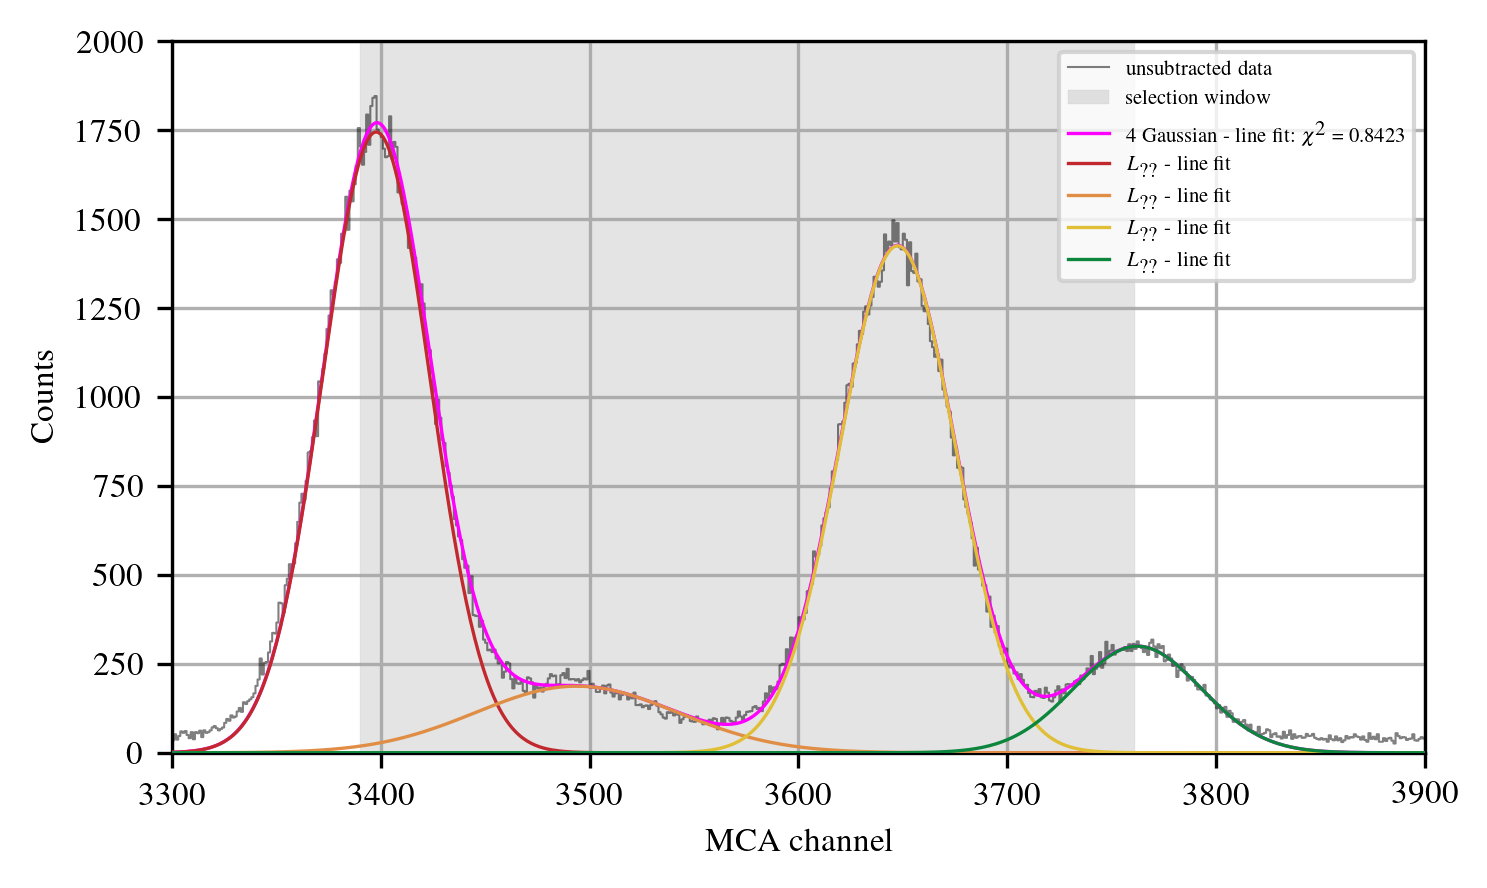

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3300, 3900]   
fit window selection:    [3390, 3761]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:  1694.604 ± 5.531
Center 1:  3397.676 ± 0.311
Width 1:     26.348 ± 0.274
FWHM 1:      62.045 ± 0.644
=========== FIT RESULTS 2 of 4 ===========
Height 2:   117.763 ± 4.659
Center 2:  3493.800 ± 1.197
Width 2:     22.940 ± 1.273
FWHM 2:      54.019 ± 2.998
=========== FIT RESULTS 3 of 4 ===========
Height 3:  1352.036 ± 4.353
Center 3:  3647.703 ± 0.099
Width 3:     26.265 ± 0.104
FWHM 3:      61.849 ± 0.246
=========== FIT RESULTS 4 of 4 ===========
Height 4:   232.515 ± 10.794
Center 4:  3760.768 ± 3.539
Width 4:     24.261 ± 2.262
FWHM 4:      57.130 ± 5.328
=========== END of FIT RESULTS ===========
lam: 10^7
GOF: 0.9979
chi²: 0.7855
red. chi²: 0.0022
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 1694.604

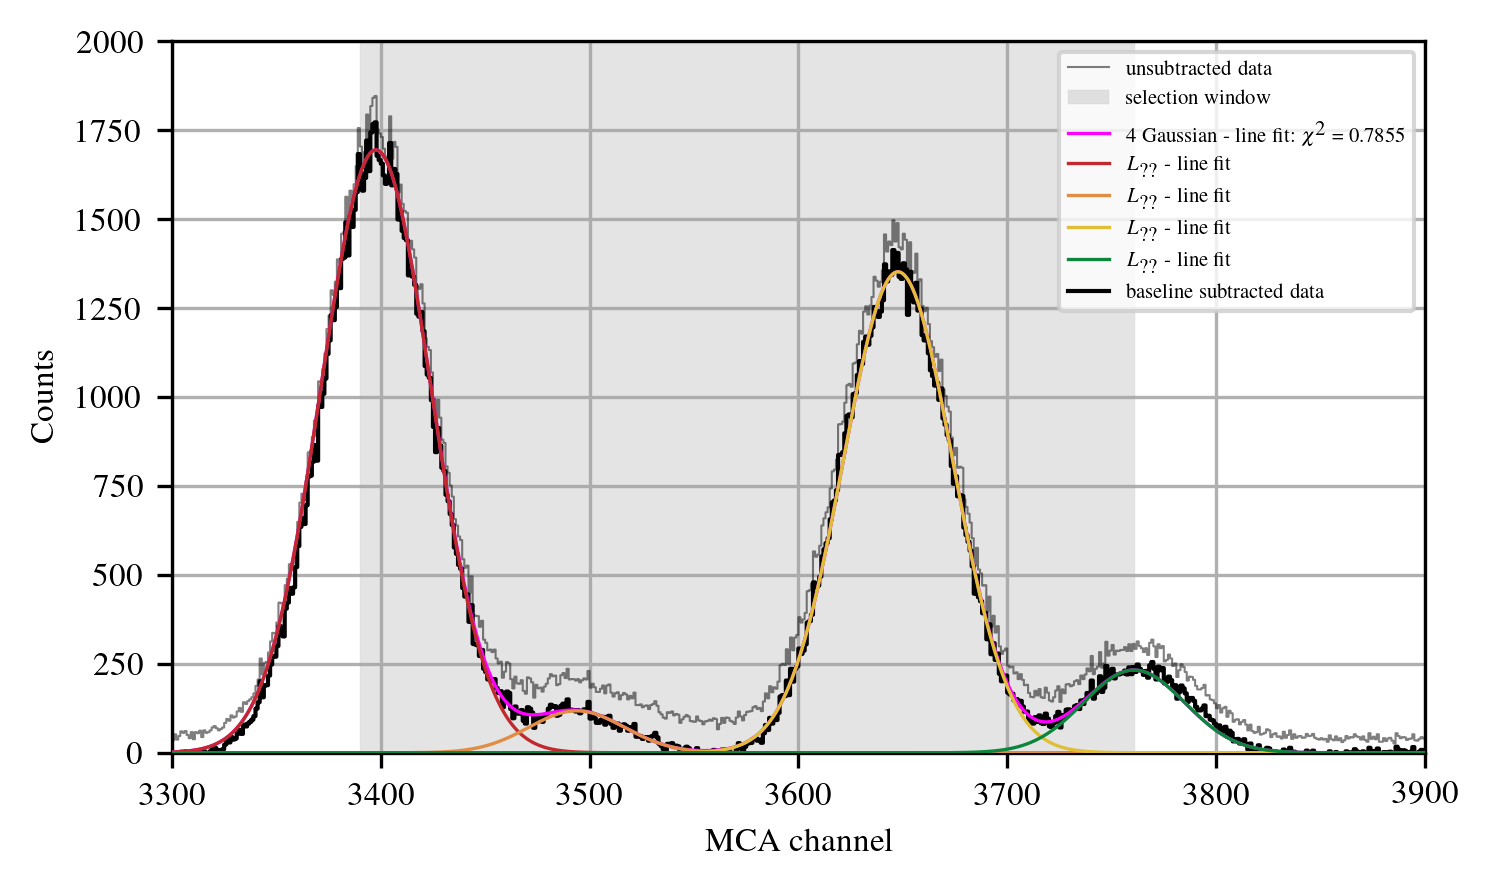

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [2850, 3280]   
fit window selection:    [2963, 3162]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height 1:   988.725 ± 5.067
Center 1:  2982.292 ± 0.282
Width 1:     26.609 ± 0.278
FWHM 1:      62.658 ± 0.654
=========== FIT RESULTS 2 of 2 ===========
Height 2:  1093.342 ± 11.844
Center 2:  3162.315 ± 0.929
Width 2:     28.705 ± 0.562
FWHM 2:      67.596 ± 1.324
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9949
chi²: 1.0199
red. chi²: 0.0053
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 988.725
Center: 7055.312 ± 185.234
Width: 63.504 ± 0.784
FWHM: 149.538 ± 1.853
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 1093.342
Center: 7484.287 ± 193.582
Width: 68.508 ± 0.846
FWHM: 161.322 ± 2.000
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_

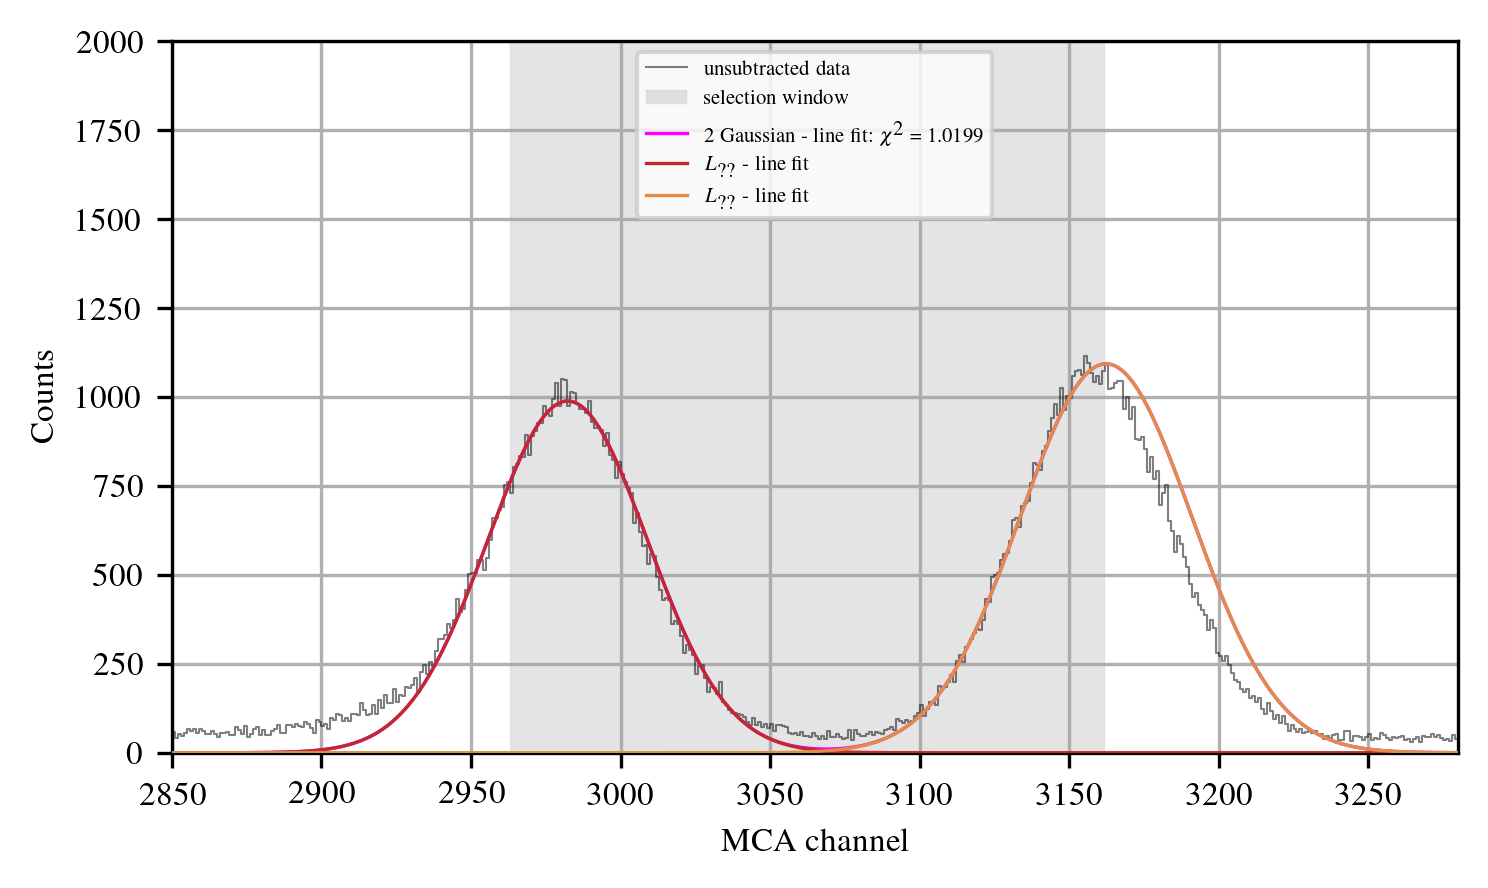

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [2850, 3280]   
fit window selection:    [2963, 3162]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height 1:   948.420 ± 3.725
Center 1:  2982.695 ± 0.179
Width 1:     24.441 ± 0.184
FWHM 1:      57.555 ± 0.432
=========== FIT RESULTS 2 of 2 ===========
Height 2:  1026.587 ± 6.220
Center 2:  3158.869 ± 0.495
Width 2:     24.882 ± 0.331
FWHM 2:      58.592 ± 0.779
=========== END of FIT RESULTS ===========
lam: 10^10
GOF: 0.9975
chi²: 0.5079
red. chi²: 0.0026
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 948.420
Center: 7056.272 ± 185.252
Width: 58.331 ± 0.720
FWHM: 137.359 ± 1.701
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 1026.587
Center: 7476.075 ± 193.420
Width: 59.383 ± 0.733
FWHM: 139.835 ± 1.732
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_

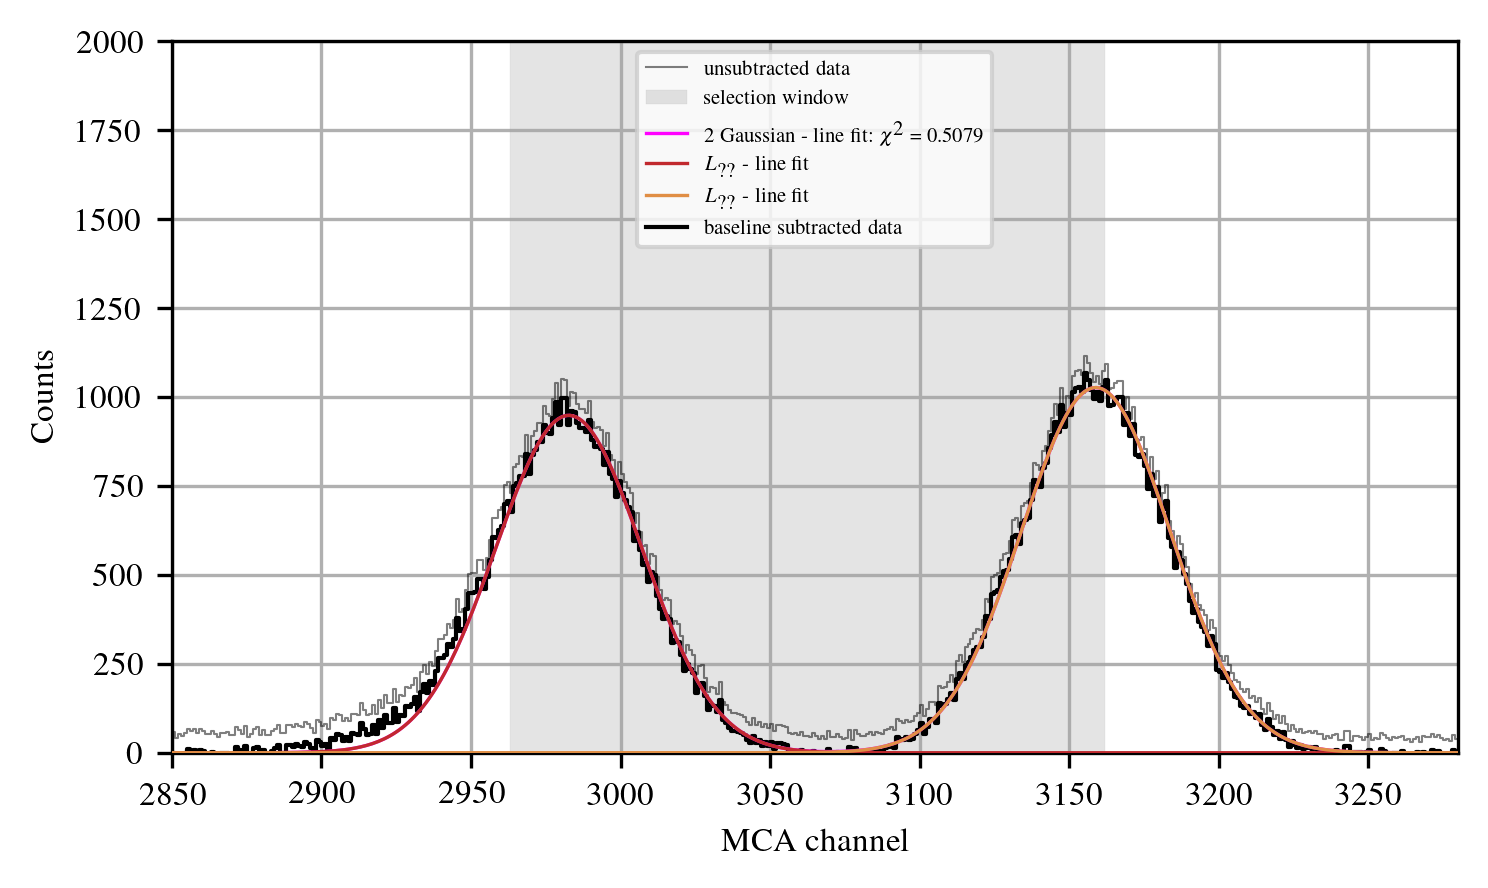

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [2150, 2850]   
fit window selection:    [2234, 2711]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1:  2280.988 ± 9.304
Center 1:  2289.361 ± 0.108
Width 1:     22.924 ± 0.109
FWHM 1:      53.981 ± 0.257
=========== FIT RESULTS 2 of 3 ===========
Height 2:   480.111 ± 8.072
Center 2:  2506.212 ± 0.588
Width 2:     30.284 ± 0.588
FWHM 2:      71.314 ± 1.384
=========== FIT RESULTS 3 of 3 ===========
Height 3:  6902.770 ± 14.285
Center 3:  2706.785 ± 0.166
Width 3:     23.984 ± 0.115
FWHM 3:      56.477 ± 0.271
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9990
chi²: 0.4761
red. chi²: 0.0010
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 2280.988
Center: 5403.766 ± 154.772
Width: 54.709 ± 0.675
FWHM: 128.829 ± 1.595
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-

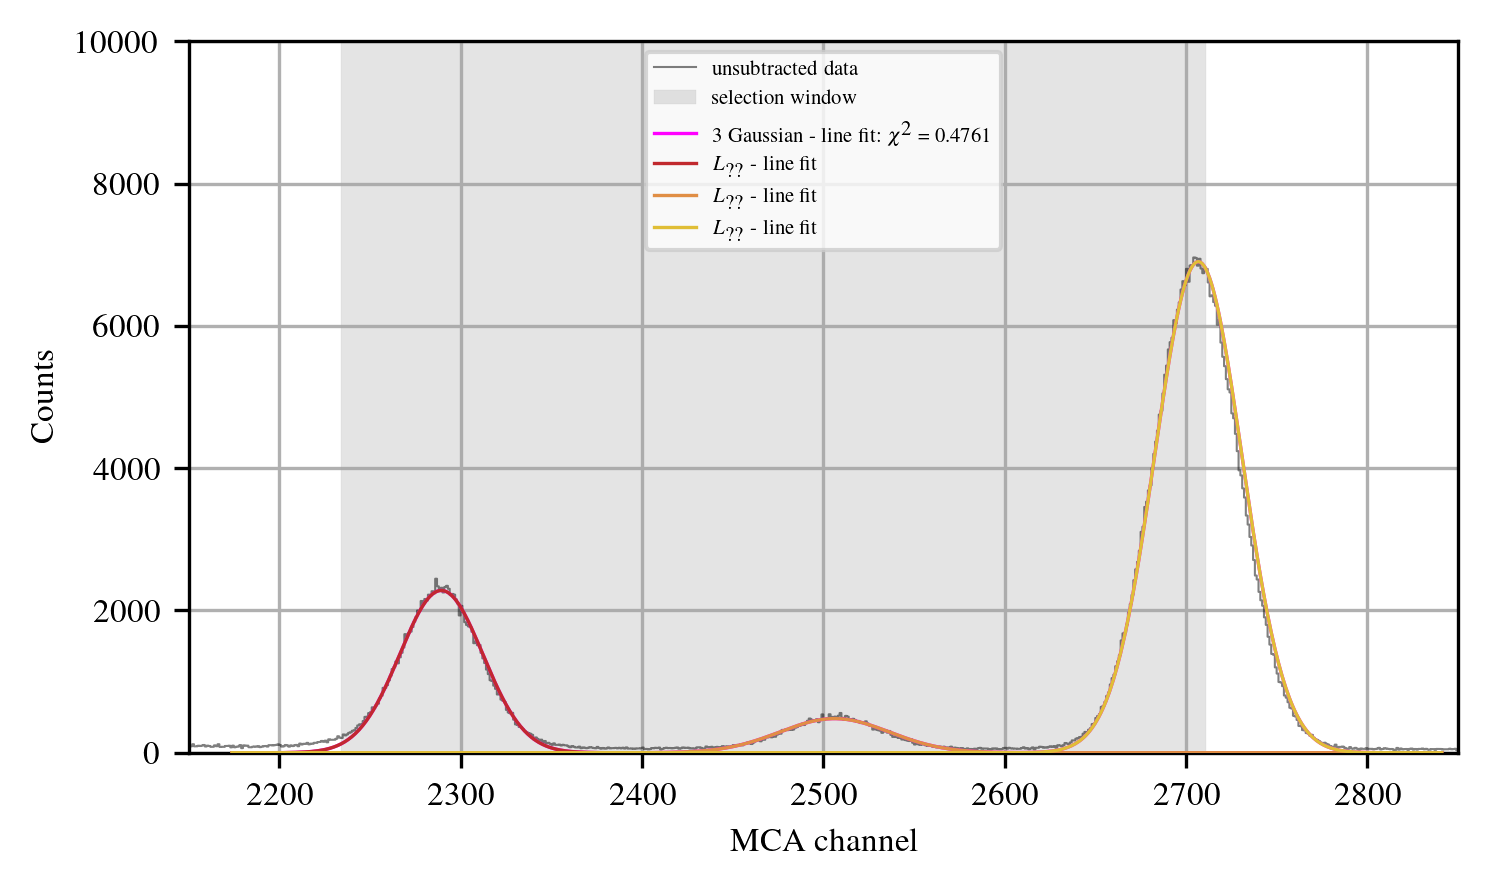

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [2150, 2850]   
fit window selection:    [2234, 2711]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1:  2213.248 ± 5.751
Center 1:  2289.453 ± 0.065
Width 1:     21.728 ± 0.066
FWHM 1:      51.165 ± 0.154
=========== FIT RESULTS 2 of 3 ===========
Height 2:   430.298 ± 5.524
Center 2:  2506.718 ± 0.348
Width 2:     23.468 ± 0.348
FWHM 2:      55.263 ± 0.819
=========== FIT RESULTS 3 of 3 ===========
Height 3:  6828.409 ± 8.328
Center 3:  2706.382 ± 0.096
Width 3:     23.412 ± 0.067
FWHM 3:      55.131 ± 0.159
=========== END of FIT RESULTS ===========
lam: 10^5
GOF: 0.9996
chi²: 0.1730
red. chi²: 0.0004
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 2213.248
Center: 5403.984 ± 154.776
Width: 51.855 ± 0.640
FWHM: 122.108 ± 1.511
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_

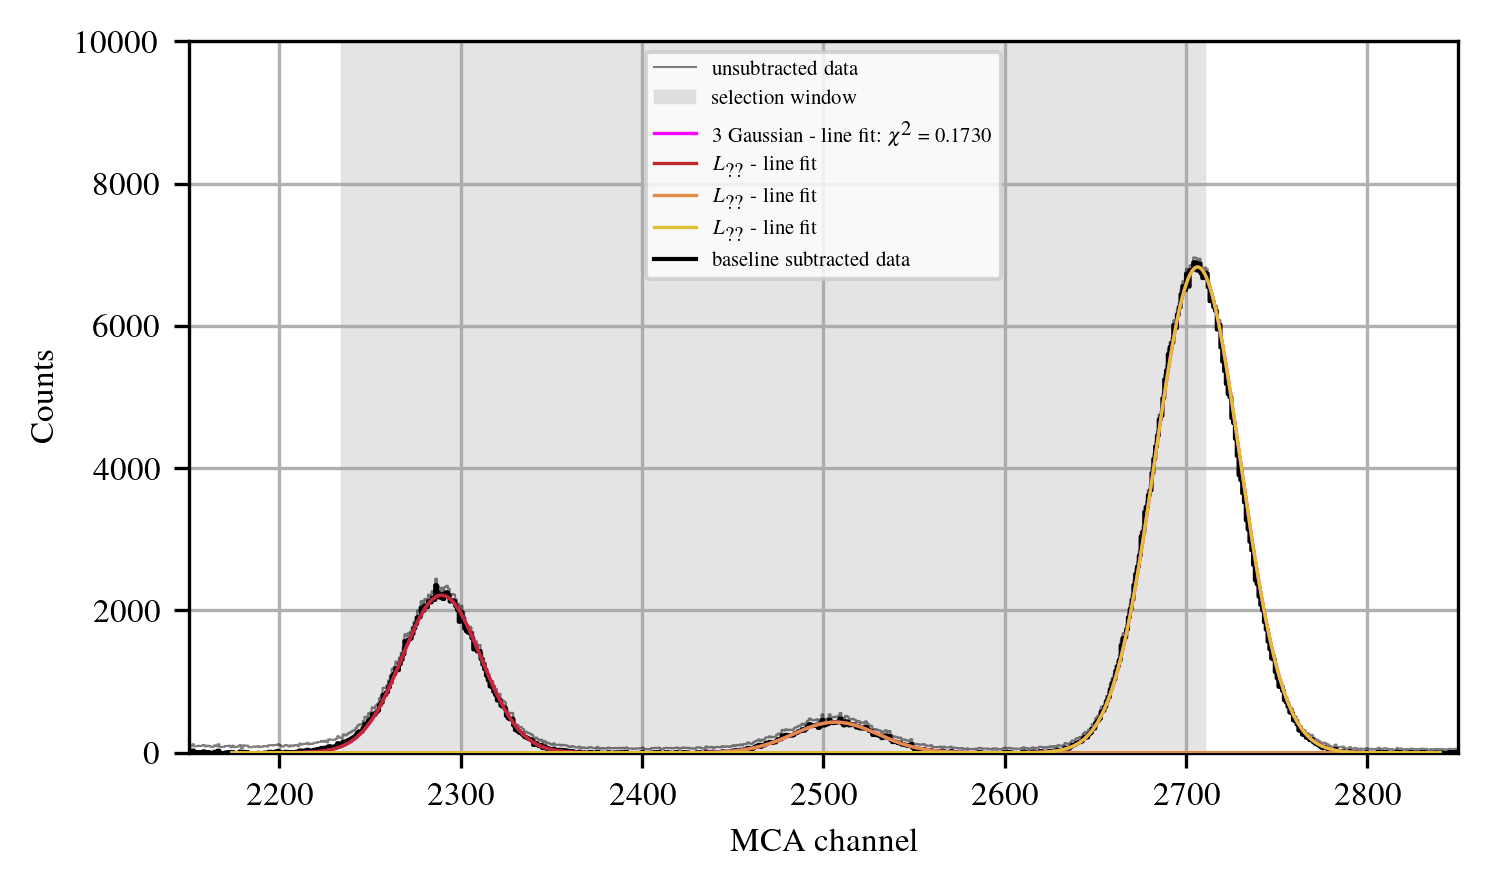

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [1730, 2110]   
fit window selection:    [1769, 2074]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:   241.228 ± 7.051
Center 1:  1797.269 ± 3.206
Width 1:     45.016 ± 6.602
FWHM 1:     106.004 ± 15.547
=========== FIT RESULTS 2 of 4 ===========
Height 2:   158.452 ± 20.451
Center 2:  1861.416 ± 0.980
Width 2:     16.936 ± 1.432
FWHM 2:      39.880 ± 3.373
=========== FIT RESULTS 3 of 4 ===========
Height 3:   395.055 ± 7.930
Center 3:  1919.003 ± 2.581
Width 3:     48.700 ± 2.200
FWHM 3:     114.680 ± 5.180
=========== FIT RESULTS 4 of 4 ===========
Height 4:   617.026 ± 4.353
Center 4:  2039.540 ± 0.230
Width 4:     23.716 ± 0.269
FWHM 4:      55.848 ± 0.634
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9741
chi²: 7.9125
red. chi²: 0.0269
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 241.228

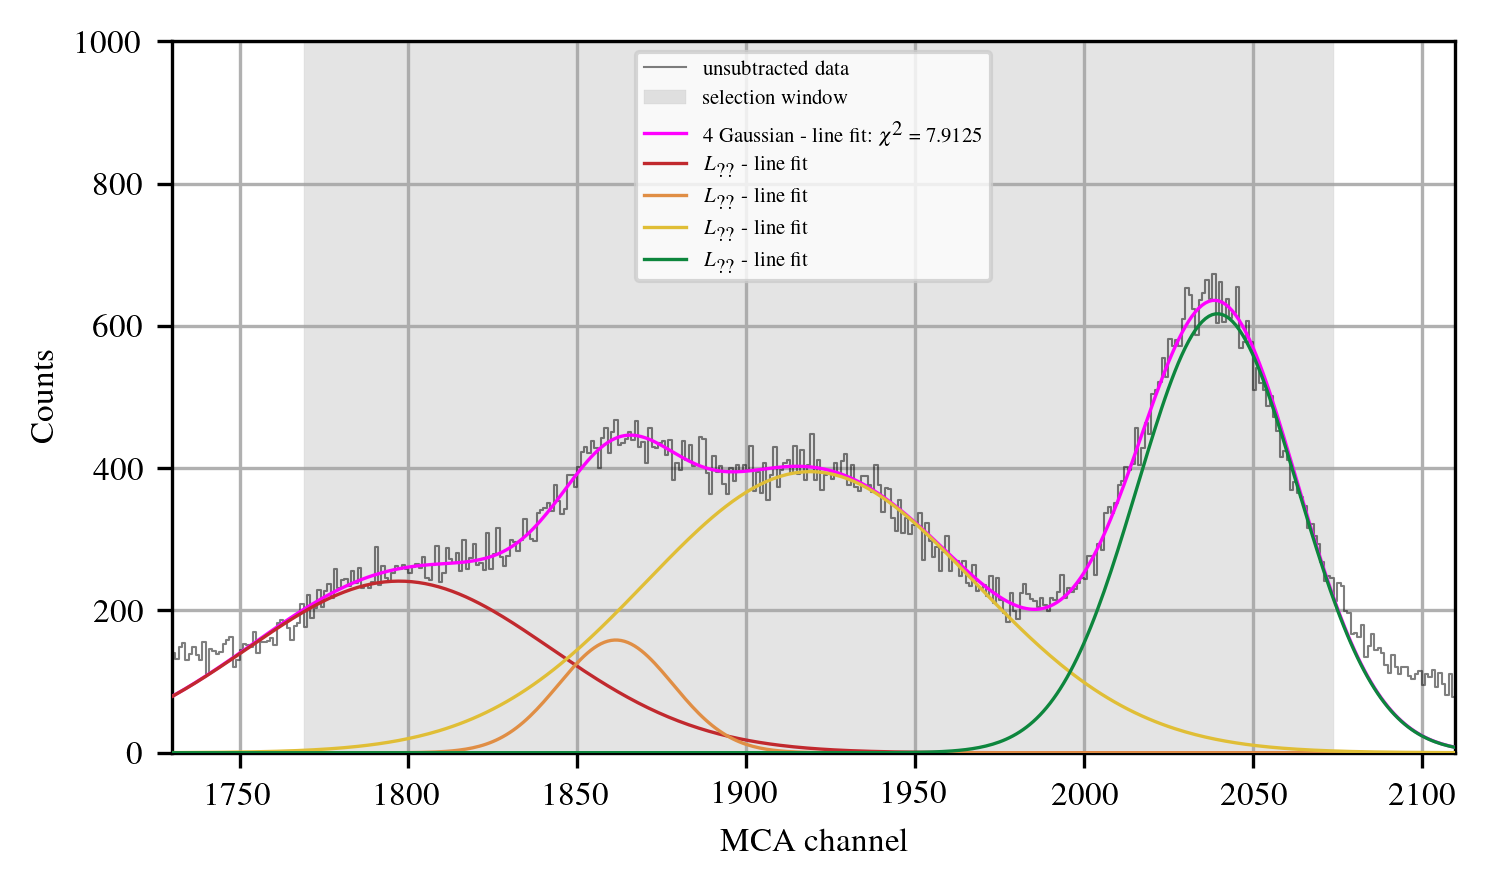

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [1730, 2110]   
fit window selection:    [1769, 2074]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:    21.857 ± 6.731
Center 1:  1782.987 ± 3.087
Width 1:      8.529 ± 3.323
FWHM 1:      20.084 ± 7.826
=========== FIT RESULTS 2 of 4 ===========
Height 2:    62.094 ± 6.416
Center 2:  1861.574 ± 1.072
Width 2:      8.988 ± 1.072
FWHM 2:      21.165 ± 2.525
=========== FIT RESULTS 3 of 4 ===========
Height 3:    31.995 ± 6.220
Center 3:  1931.934 ± 2.147
Width 3:      9.564 ± 2.147
FWHM 3:      22.521 ± 5.056
=========== FIT RESULTS 4 of 4 ===========
Height 4:   472.232 ± 4.484
Center 4:  2039.131 ± 0.209
Width 4:     18.970 ± 0.221
FWHM 4:      44.671 ± 0.520
=========== END of FIT RESULTS ===========
lam: 10^5
GOF: 0.9785
chi²: 6.5904
red. chi²: 0.0224
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 21.857
Ce

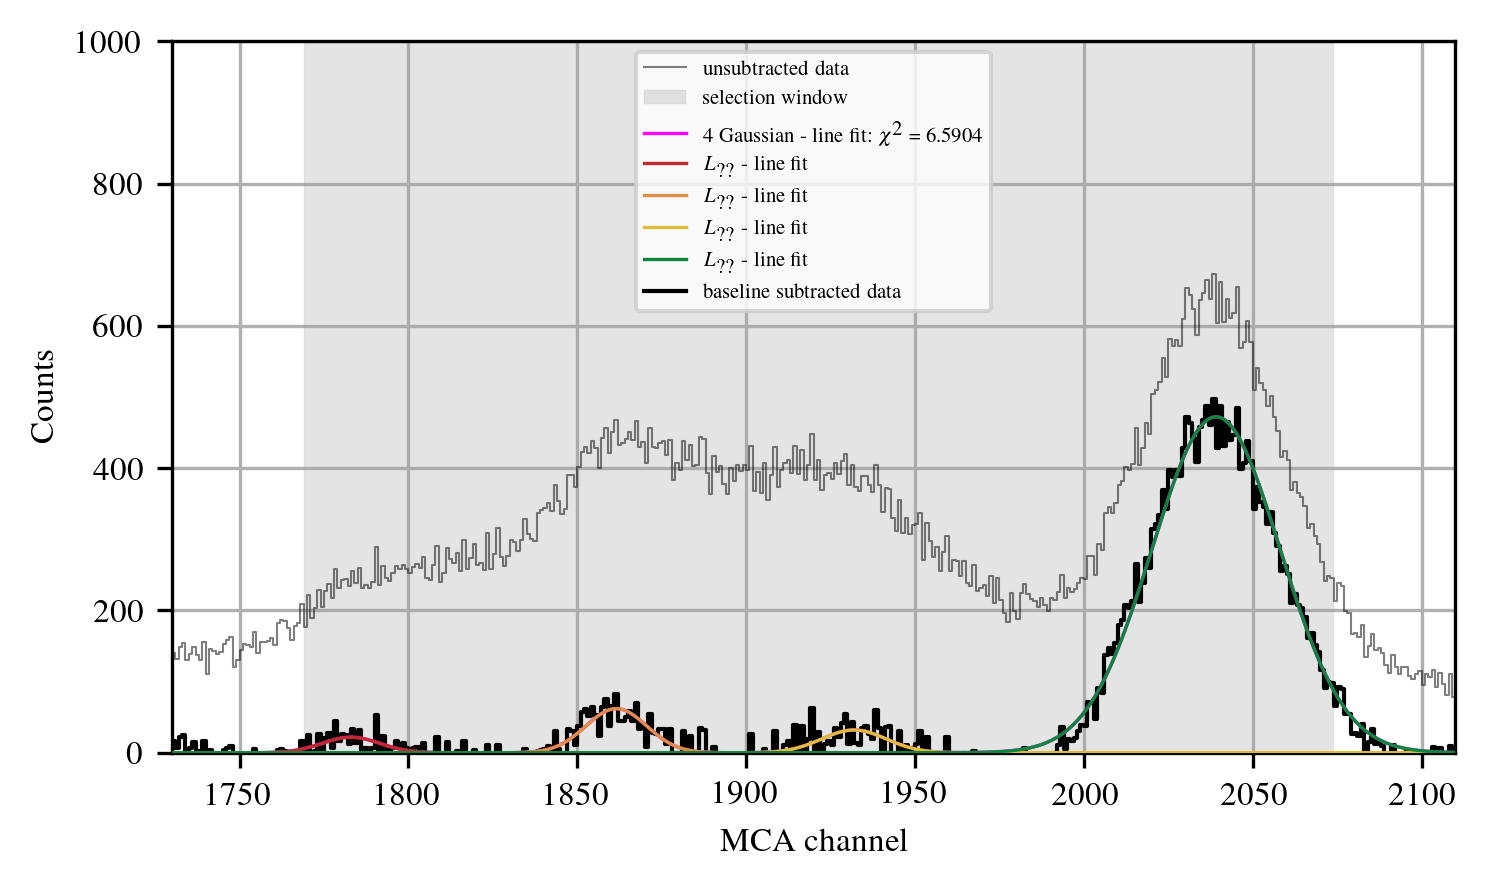

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [570, 1160]    
fit window selection:    [629, 763]     
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height A:   132.211 ± 2.042
Center A:   649.470 ± 1.496
Width A:     38.923 ± 3.818
FWHM A:      53.959 ± 5.293
=========== FIT RESULTS 2 of 2 ===========
Height B:   133.433 ± 4.178
Center B:   739.812 ± 1.134
Width B:     25.262 ± 1.489
FWHM B:      35.020 ± 2.065
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.6750
chi²: 43.8690
red. chi²: 0.3401
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 132.211
Center: 1492.909 ± 93.248
Width: 92.893 ± 1.149
FWHM: 218.744 ± 2.718
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 133.433
Center: 1708.443 ± 96.251
Width: 60.289 ± 0.744
FWHM: 141.968 ± 1.759
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-

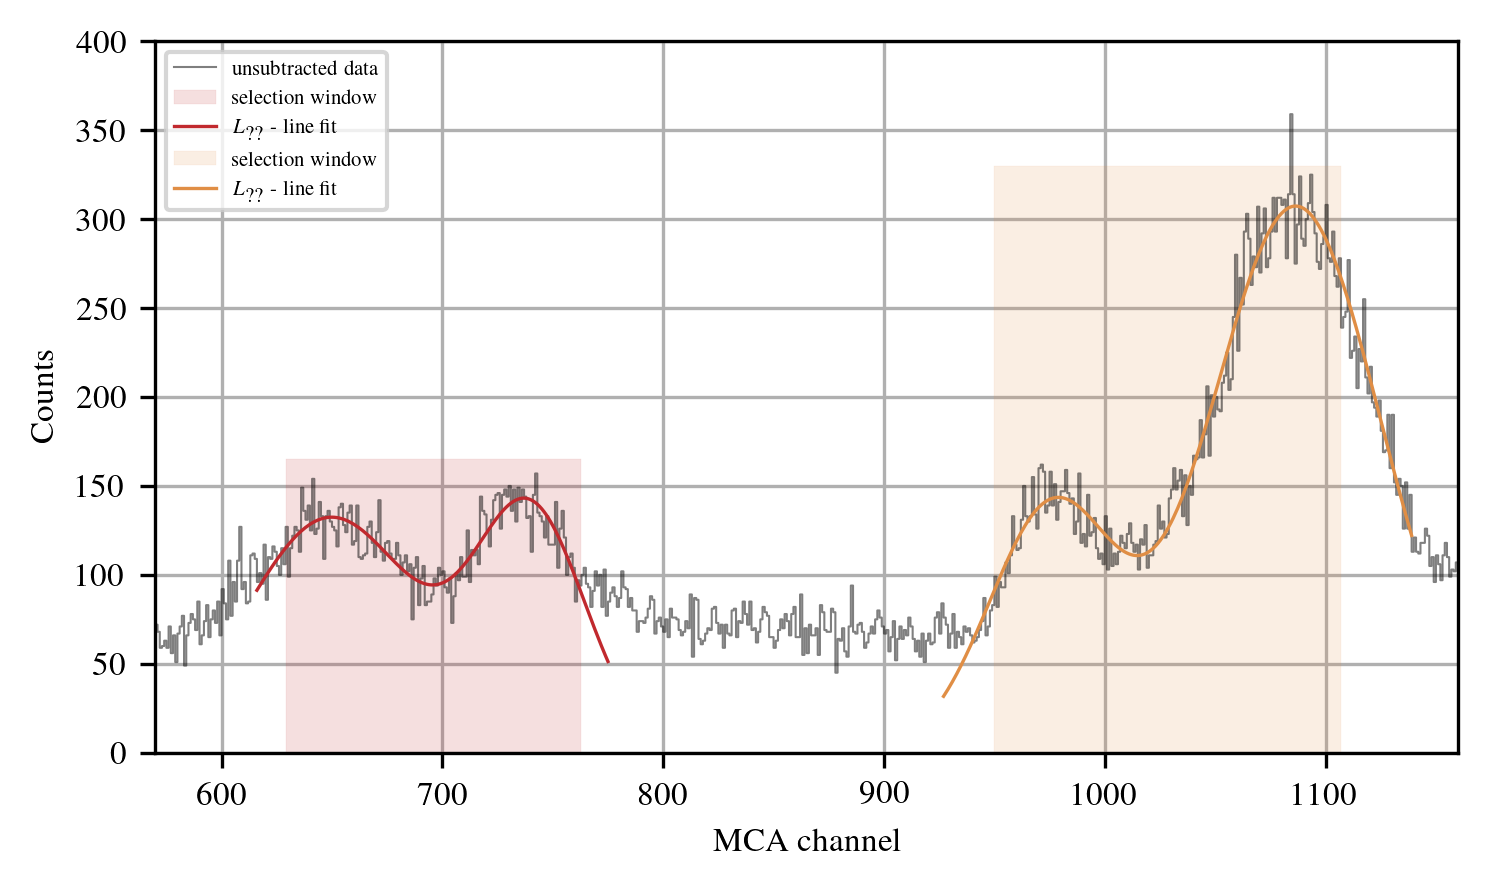

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [570, 1160]    
fit window selection:    [629, 763]     
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height A:    30.902 ± 2.803
Center A:   645.581 ± 2.220
Width A:     16.314 ± 2.433
FWHM A:      22.616 ± 3.373
=========== FIT RESULTS 2 of 2 ===========
Height B:    46.677 ± 2.999
Center B:   736.492 ± 0.986
Width B:     13.276 ± 1.021
FWHM B:      18.404 ± 1.416
=========== END of FIT RESULTS ===========
lam: 10^6
GOF: 0.6603
chi²: 45.8652
red. chi²: 0.3555
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 30.902
Center: 1483.631 ± 93.120
Width: 38.934 ± 0.480
FWHM: 91.682 ± 1.134
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 46.677
Center: 1700.522 ± 96.140
Width: 31.684 ± 0.391
FWHM: 74.609 ± 0.922
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-

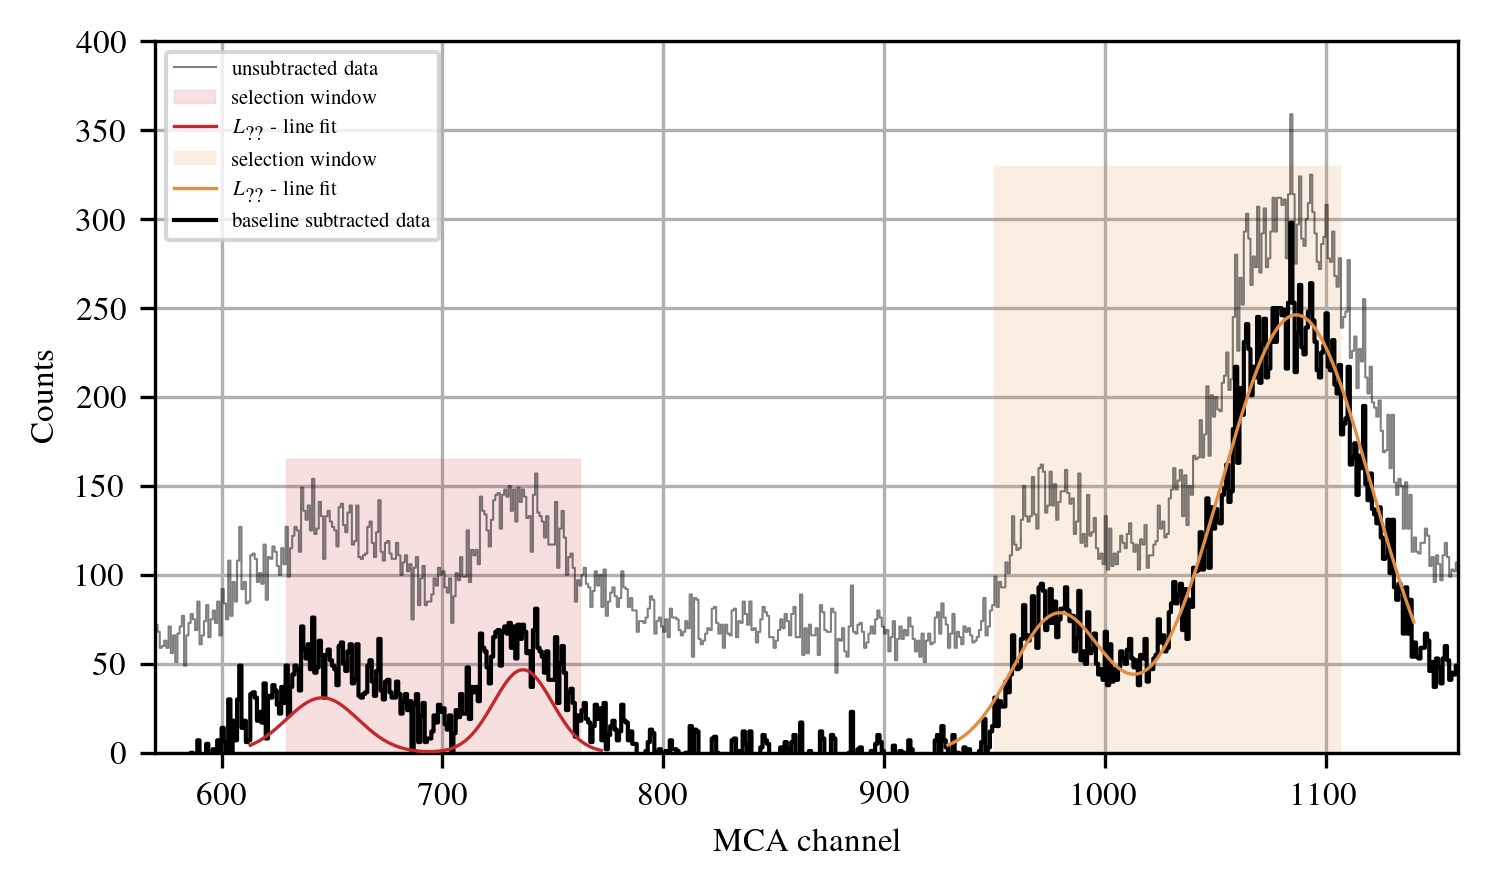

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3900, 4600]   
fit window selection:    [4022, 4047]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS ===========
Height:   119.563 ± 2.472
Center:  4041.645 ± 3.388
Width:     26.499 ± 5.996
FWHM:      36.735 ± 8.312
=========== FIT RESULTS ===========
lam: 10^2
GOF: 0.5319
chi²: 12.1705
red. chi²: 0.5292
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 119.563
Center: 9579.074 ± 236.930
Width: 63.241 ± 0.781
FWHM: 148.921 ± 1.845
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3900, 4600]   
fit window selection:    [4453, 4476]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS ===========
Height:    88.955 ± 2.872
Center:  4458.722 ± 10.754
Width:     38.110 ± 31.910
FWHM:      52.831 ± 44.236
======

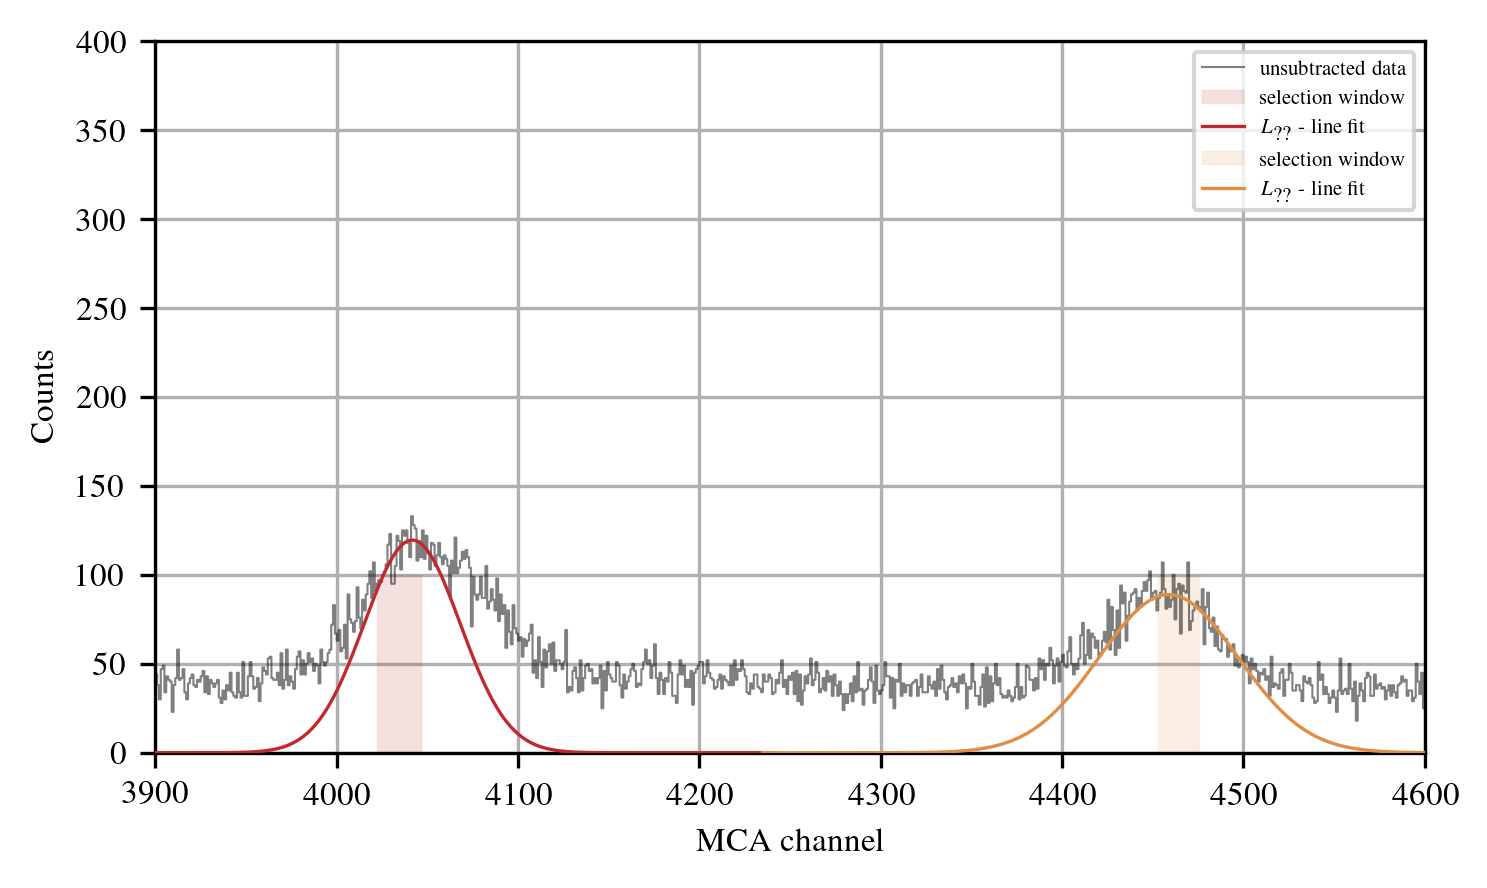

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3900, 4600]   
fit window selection:    [4022, 4047]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS ===========
Height:    68.727 ± 2.502
Center:  4041.512 ± 3.150
Width:     19.173 ± 4.308
FWHM:      26.580 ± 5.973
=========== FIT RESULTS ===========
lam: 10^6
GOF: 0.5216
chi²: 12.4381
red. chi²: 0.5408
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 68.727
Center: 9578.758 ± 236.923
Width: 45.759 ± 0.565
FWHM: 107.753 ± 1.333
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [3900, 4600]   
fit window selection:    [4453, 4476]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS ===========
Height:    38.889 ± 2.923
Center:  4458.412 ± 12.776
Width:     26.635 ± 26.006
FWHM:      36.924 ± 36.052
=======

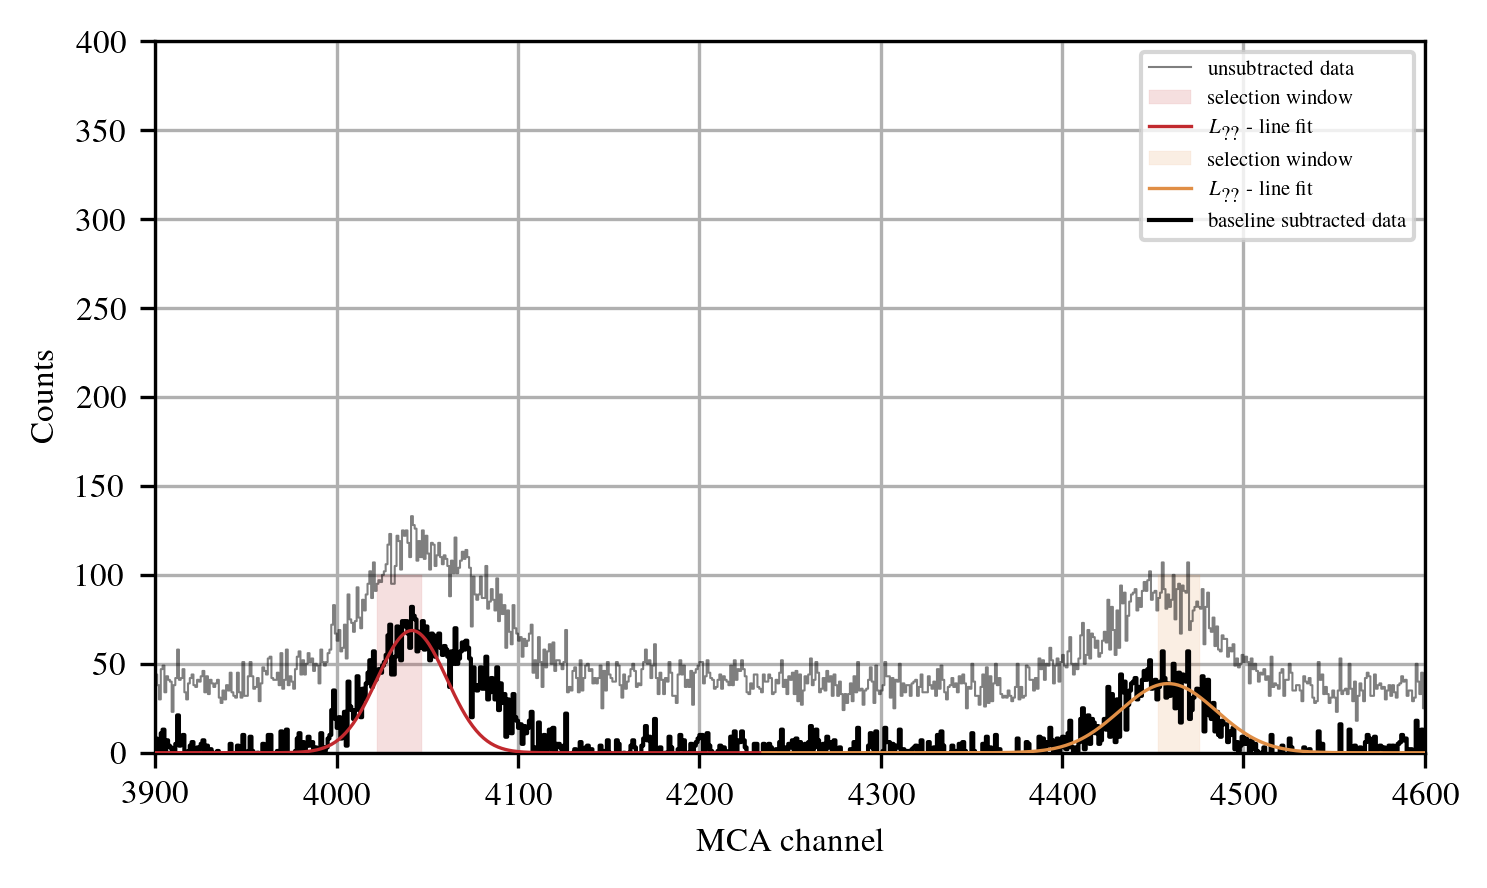

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [4800, 5200]   
fit window selection:    [4880, 5192]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:   328.253 ± 19.741
Center 1:  4909.518 ± 1.749
Width 1:     36.318 ± 1.627
FWHM 1:      85.523 ± 3.831
=========== FIT RESULTS 2 of 4 ===========
Height 2:  1429.818 ± 66.982
Center 2:  5018.389 ± 0.185
Width 2:     32.743 ± 0.599
FWHM 2:      77.104 ± 1.411
=========== FIT RESULTS 3 of 4 ===========
Height 3:   144.042 ± 14.378
Center 3:  5096.604 ± 28.731
Width 3:     76.049 ± 24.430
FWHM 3:     179.082 ± 57.527
=========== FIT RESULTS 4 of 4 ===========
Height 4:    12.125 ± 13.568
Center 4:  5187.161 ± 3.669
Width 4:      3.249 ± 4.651
FWHM 4:       7.650 ± 10.952
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.9977
chi²: 0.7048
red. chi²: 0.0023
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 3

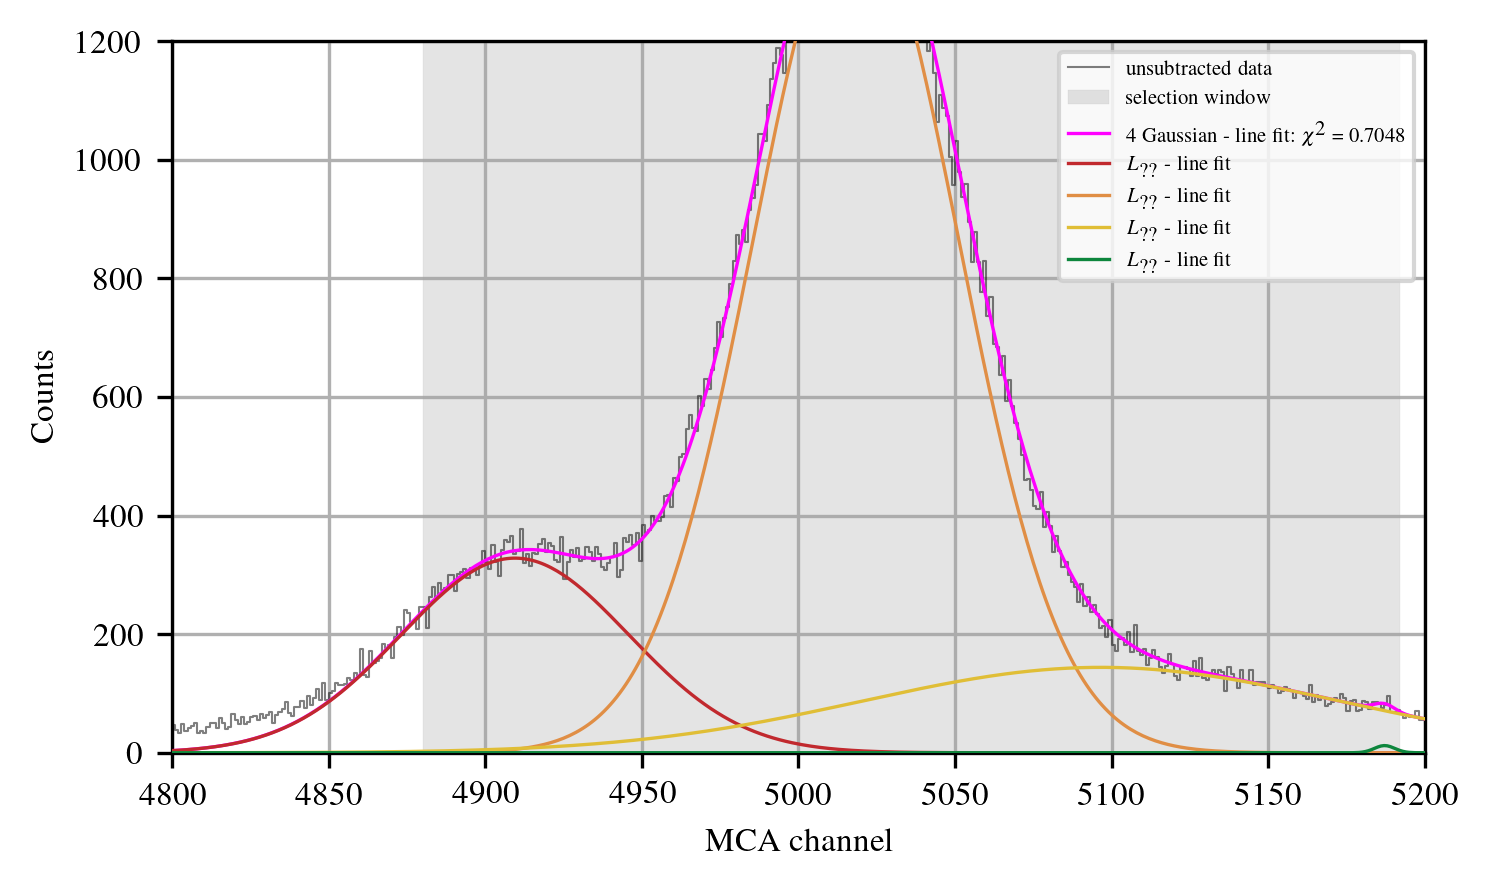

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [4800, 5200]   
fit window selection:    [4880, 5192]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 4 ===========
Height 1:   268.334 ± 42.319
Center 1:  4910.172 ± 5.573
Width 1:     33.215 ± 4.456
FWHM 1:      78.215 ± 10.492
=========== FIT RESULTS 2 of 4 ===========
Height 2:  1388.565 ± 231.753
Center 2:  5018.516 ± 0.787
Width 2:     32.426 ± 1.578
FWHM 2:      76.357 ± 3.715
=========== FIT RESULTS 3 of 4 ===========
Height 3:    75.883 ± 101.659
Center 3:  5069.298 ± 161.215
Width 3:     62.152 ± 83.390
FWHM 3:     146.357 ± 196.369
=========== FIT RESULTS 4 of 4 ===========
Height 4:   -23.901 ± 17.227
Center 4:  5183.085 ± 11.488
Width 4:     18.594 ± 14.563
FWHM 4:      43.786 ± 34.294
=========== END of FIT RESULTS ===========
lam: 10^9
GOF: 0.9978
chi²: 0.6968
red. chi²: 0.0023
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
He

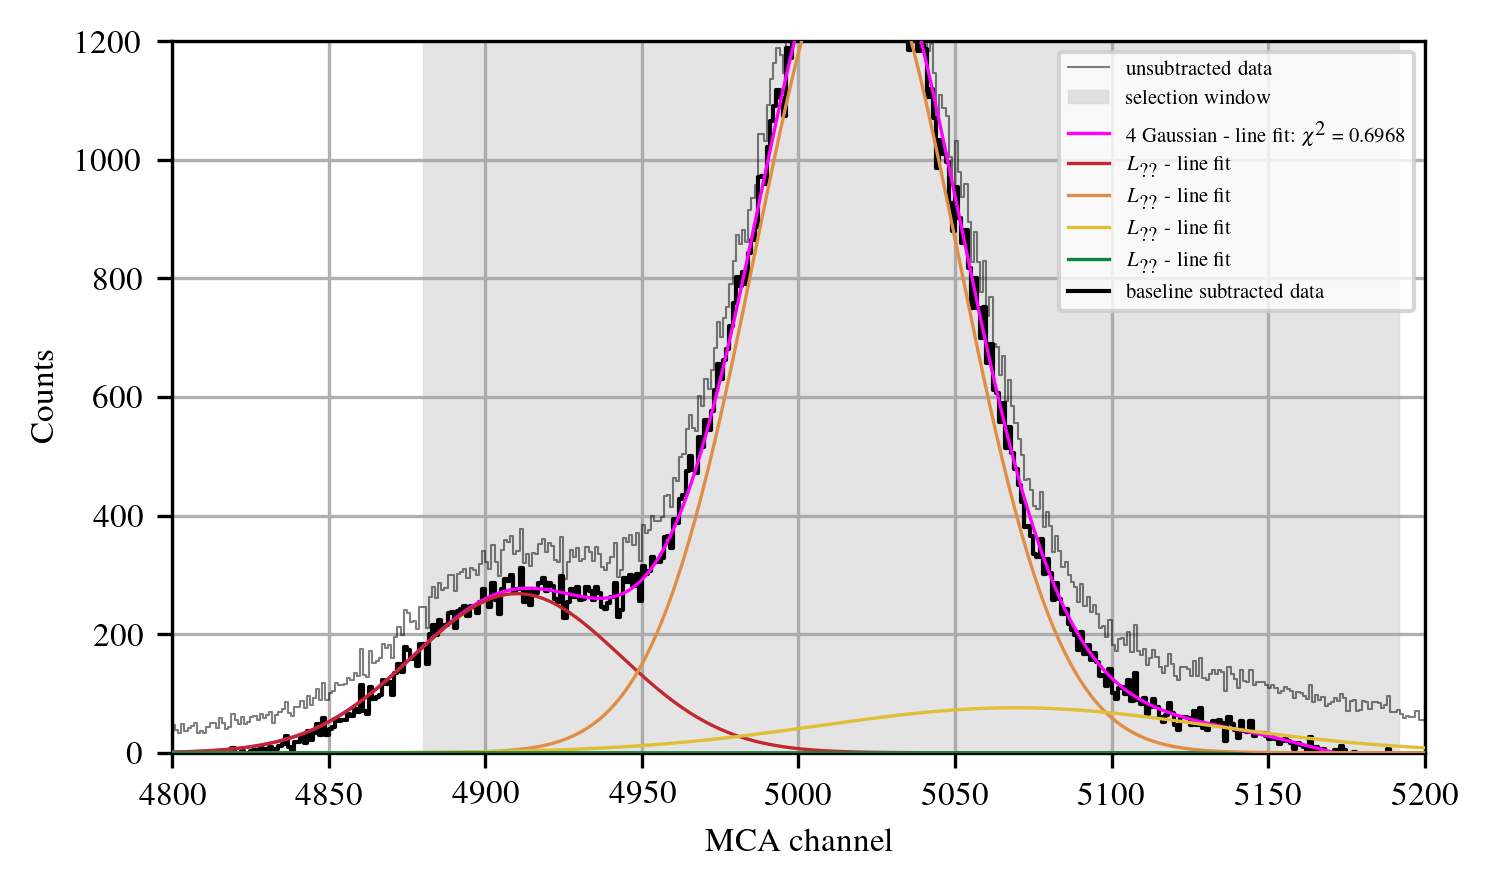

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [5200, 5570]   
fit window selection:    [5309, 5481]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height 1:    64.526 ± 1.278
Center 1:  5326.760 ± 3.013
Width 1:     46.394 ± 6.374
FWHM 1:     109.249 ± 15.010
=========== FIT RESULTS 2 of 2 ===========
Height 2:   104.598 ± 4.880
Center 2:  5487.089 ± 8.284
Width 2:     50.865 ± 7.978
FWHM 2:     119.778 ± 18.786
=========== END of FIT RESULTS ===========
lam: 10^2
GOF: 0.8505
chi²: 25.8598
red. chi²: 0.1548
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 64.526
Center: 12638.867 ± 307.966
Width: 110.722 ± 1.370
FWHM: 260.725 ± 3.245
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 104.598
Center: 13020.464 ± 317.468
Width: 121.393 ± 1.503
FWHM: 285.853 ± 3.561
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_

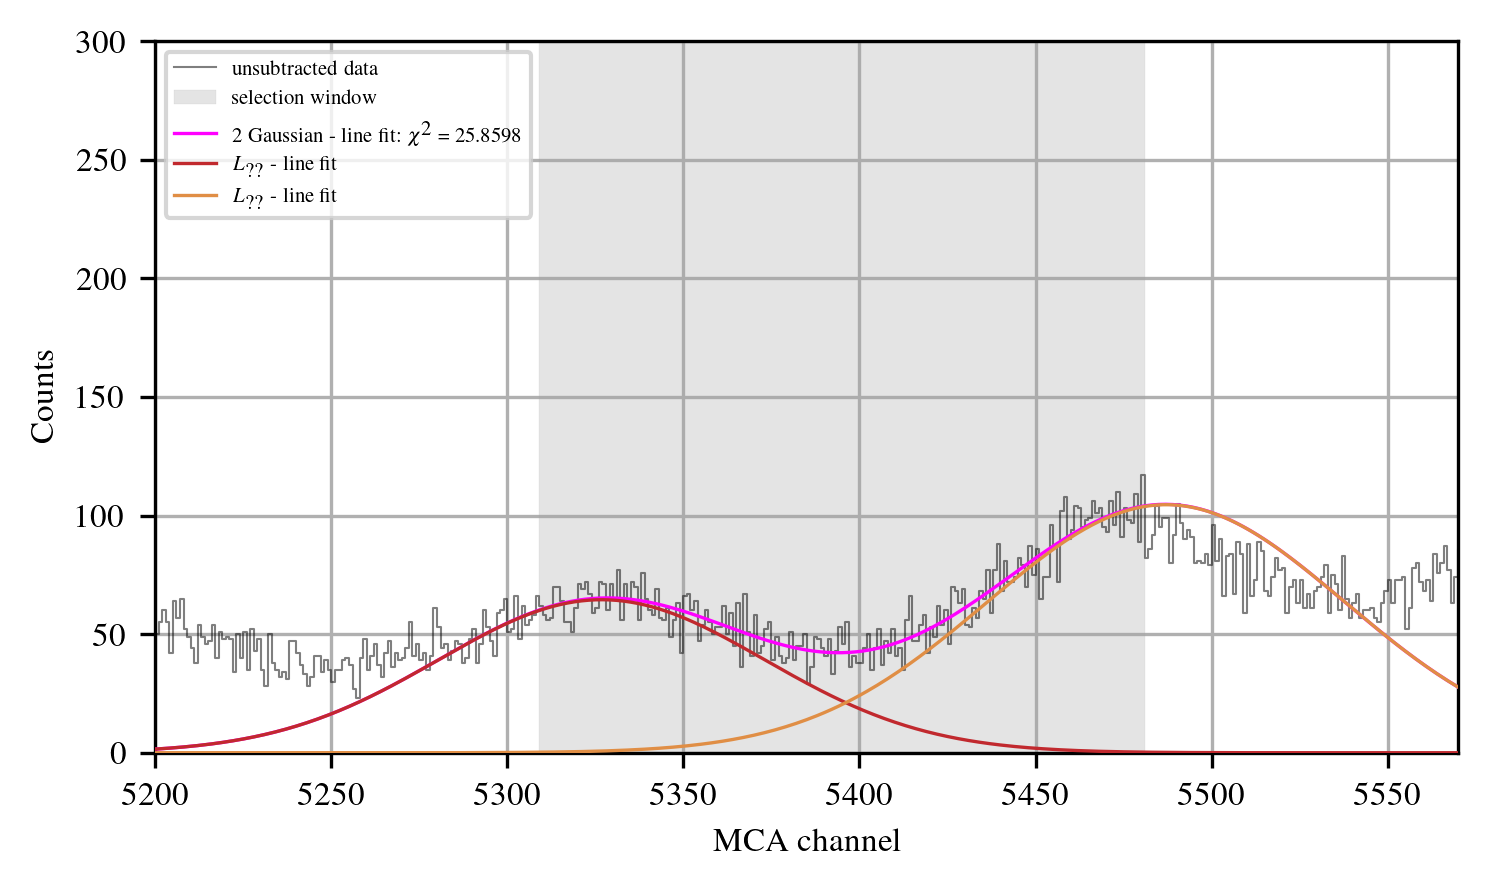

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [5200, 5570]   
fit window selection:    [5309, 5481]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 2 ===========
Height 1:    14.062 ± 4.697
Center 1:  5367.747 ± 0.803
Width 1:      2.093 ± 0.817
FWHM 1:       4.929 ± 1.924
=========== FIT RESULTS 2 of 2 ===========
Height 2: 59185856828063.781 ± 232898587073325888.000
Center 2: 12424.605 ± 915489.518
Width 2:    898.986 ± 58694.160
FWHM 2:    2116.950 ± 138214.185
=========== END of FIT RESULTS ===========
lam: 10^0
GOF: 0.0921
chi²: 157.0751
red. chi²: 0.9406
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 14.062
Center: 12736.423 ± 310.381
Width: 4.995 ± 0.062
FWHM: 11.763 ± 0.145
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
|-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_|
Height: 59185856828063.781
Center: 29502.585 ± 864.645
Width: 2145.032 ± 28.662
FWHM: 5049

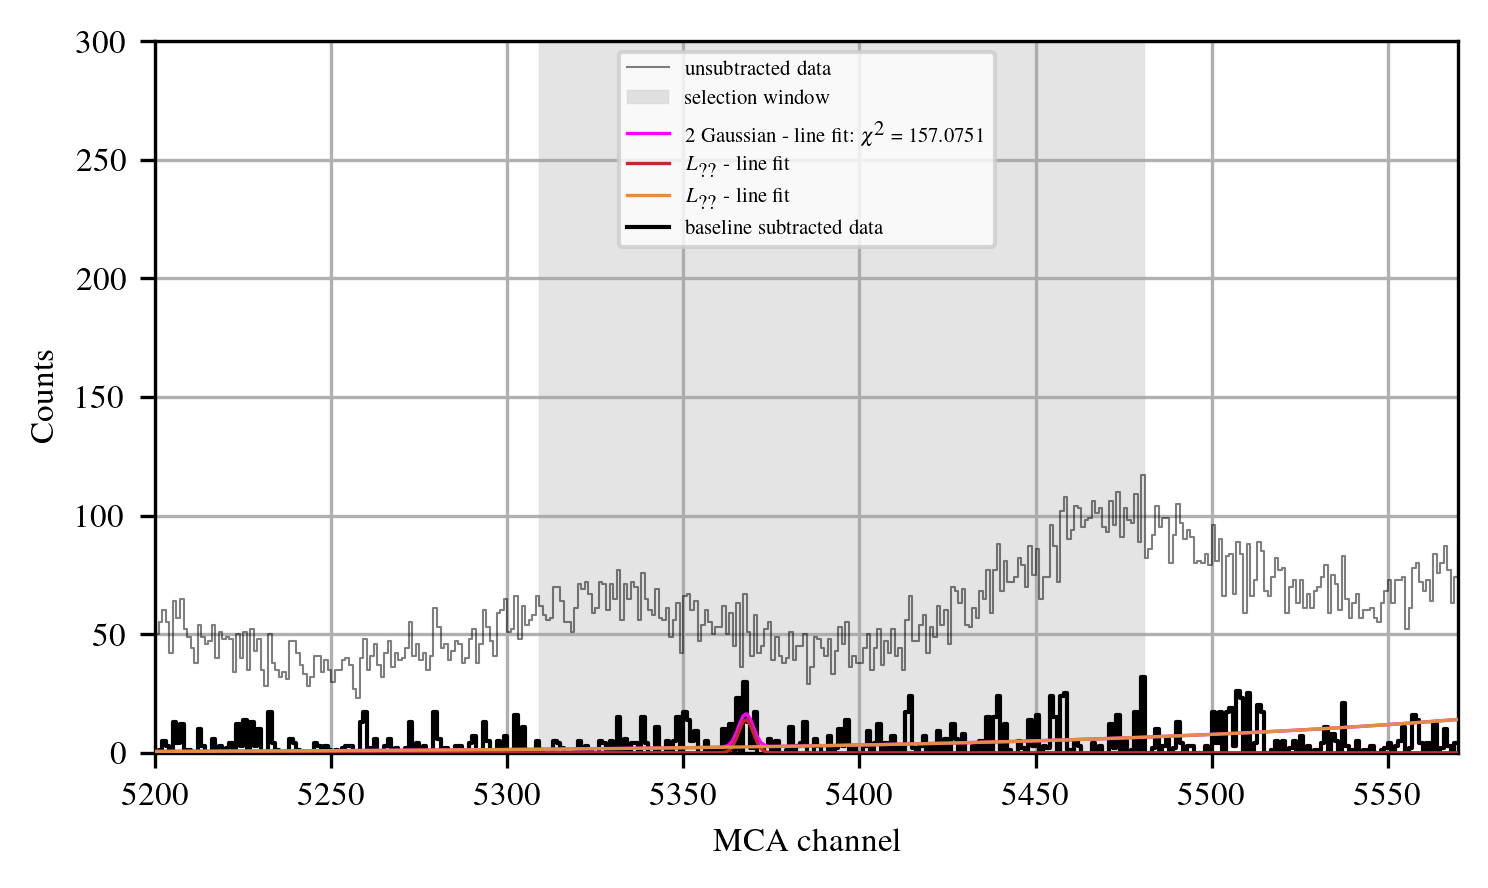

IndexError: list index out of range

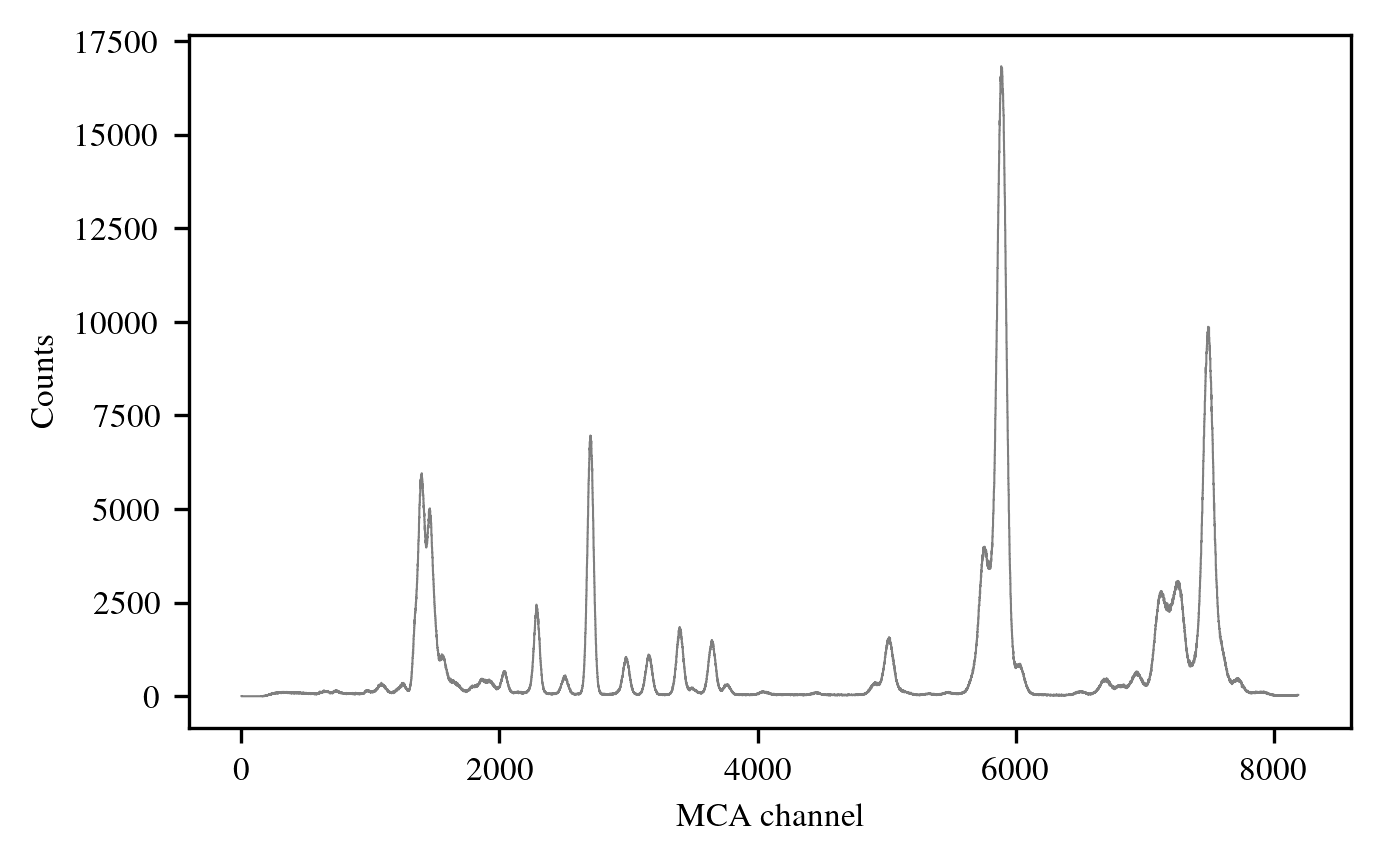

In [ ]:
file_to_analyze = './/collected_data//2026_05_13//20260513-060516.vspc'

init_val1 = [[400,1250,10,2000,1344,10,6000,1380,15,5000,1455,15,1000,1500,15,600,1570,15]]
xlim1 = [1150,1650]
ylim1 = [0,6250]
info1 = ['Harwell Source', r'$M_{??}$', r'$M_5N_{6,7}$', r'$M_4N_6 + M_5O_3$', r'$M_3N{4,5} + M_5P_3$', r'$M_{???}$', '???']
gauss1 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=False, identifier='01s', gauss_ident=gauss1, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=False, identifier='01s_arPLS', gauss_ident=gauss1, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val2 = [[3000,5720,25,16000,5892,15,800,6050,15]]
xlim2 = [5530,6100]
ylim2 = [0,18000]
info2 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$',]
gauss2 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='02s', gauss_ident=gauss2, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='02s_arPLS', gauss_ident=gauss2, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val3 = [[2000,3400,50,200,3480,15,1500,3648,20,300,3750,15]]
xlim3 = [3300,3900]
ylim3 = [0,2000]
info3 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss3 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=False, identifier='03s', gauss_ident=gauss3, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=False, identifier='03s_arPLS', gauss_ident=gauss3, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val4 = [[1000,2975,20,1000,3150,20]]
xlim4 = [2850,3280]
ylim4 = [0,2000]
info4 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss4 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val4, xlim=xlim4, ylim=ylim4, info=info4, col_flag=False, identifier='04s', gauss_ident=gauss4, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val4, xlim=xlim4, ylim=ylim4, info=info4, col_flag=False, identifier='04s_arPLS', gauss_ident=gauss4, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val5 = [[1100,2280,15,500,2500,15,5000,2700,15]]
xlim5 = [2150,2850]
ylim5 = [0,10000]
info5 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss5 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val5, xlim=xlim5, ylim=ylim5, info=info5, col_flag=False, identifier='05s', gauss_ident=gauss5, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val5, xlim=xlim5, ylim=ylim5, info=info5, col_flag=False, identifier='05s_arPLS', gauss_ident=gauss5, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val6 = [[200,1780,20,400,1850,20,400,1920,20,600,2050,20]]
xlim6 = [1730,2110]
ylim6 = [0,1000]
info6 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss6 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val6, xlim=xlim6, ylim=ylim6, info=info6, col_flag=False, identifier='06s', gauss_ident=gauss6, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val6, xlim=xlim6, ylim=ylim6, info=info6, col_flag=False, identifier='06s_arPLS', gauss_ident=gauss6, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e7)

init_val7 = [[150,640,20,150,750,15],[150,960,15,300,1095,15]]
xlim7 = [570,1160]
ylim7 = [0,400]
info7 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss7 = ['double','double']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val7, xlim=xlim7, ylim=ylim7, info=info7, col_flag=False, identifier='07s', gauss_ident=gauss7, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val7, xlim=xlim7, ylim=ylim7, info=info7, col_flag=False, identifier='07s_arPLS', gauss_ident=gauss7, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val8 = [[100,4035,15],[100,4465,15]]
xlim8 = [3900,4600]
ylim8 = [0,400]
info8 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss8 = ['single','single']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val8, xlim=xlim8, ylim=ylim8, info=info8, col_flag=False, identifier='08s', gauss_ident=gauss8, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val8, xlim=xlim8, ylim=ylim8, info=info8, col_flag=False, identifier='08s_arPLS', gauss_ident=gauss8, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val9 = [[300,4890,20,1000,5010,20,100,5130,15,100,5180,10]]
xlim9 = [4800,5200]
ylim9 = [0,1200]
info9 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss9 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val9, xlim=xlim9, ylim=ylim9, info=info9, col_flag=False, identifier='09s', gauss_ident=gauss9, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val9, xlim=xlim9, ylim=ylim9, info=info9, col_flag=False, identifier='09s_arPLS', gauss_ident=gauss9, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val10 = [[100,5320,20,100,5470,20]]
xlim10 = [5200,5570]
ylim10 = [0,300]
info10 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss10 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val10, xlim=xlim10, ylim=ylim10, info=info10, col_flag=False, identifier='10s', gauss_ident=gauss10, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val10, xlim=xlim10, ylim=ylim10, info=info10, col_flag=False, identifier='10s_arPLS', gauss_ident=gauss10, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val11 = [[100,6490,20,300,6666,20,200,6800,20,400,6950,20,2000,7120,20,2000,7250,20]]
xlim11 = [6350,7370]
ylim11 = []
info11 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss11 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val11, xlim=xlim11, ylim=ylim11, info=info11, col_flag=False, identifier='11s', gauss_ident=gauss11, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val11, xlim=xlim11, ylim=ylim11, info=info11, col_flag=False, identifier='11s_arPLS', gauss_ident=gauss11, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)

init_val11 = [[10000,7490,20,1000,7540,20,1000,7615,20,300,7700,20,100,7830,20,100,7900,20]]
xlim11 = [7350,8020]
ylim11 = [0,20000]
info11 = ['Harwell Source', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$', r'$L_{??}$']
gauss11 = ['multi']

selection_fitter_plotter(file = file_to_analyze, peaks = init_val11, xlim=xlim11, ylim=ylim11, info=info11, col_flag=False, identifier='11s', gauss_ident=gauss11, s_flag=False, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val11, xlim=xlim11, ylim=ylim11, info=info11, col_flag=False, identifier='11s_arPLS', gauss_ident=gauss11, s_flag=True, r_flag='roi_x', chi_flag=True, lam=1e6)